Importy

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import joblib
import glob
import itertools
import copy
import os

Wspólne klasy i funkcje sieci

In [ ]:
class SubNetwork(nn.Module):
    def __init__(self, input_dim, output_dim=1):
        super(SubNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, output_dim)
        )
    def forward(self, x): return self.net(x)

def train_greybox_model(model, dataloader, epochs=2000, patience=80, min_delta=1e-6):
    optimizer = optim.Adam(model.parameters(), lr=5e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.95)
    criterion = nn.L1Loss() 
    
    # --- Zmienne dla Early Stopping ---
    best_loss = float('inf') # Ustawiamy początkowy "najlepszy" błąd na nieskończoność
    patience_counter = 0     # Licznik epok bez poprawy
    best_model_weights = copy.deepcopy(model.state_dict()) # Tu będziemy trzymać kopię najlepszych wag
    
    model.train()
    print(f"Rozpoczynam trening (Maksymalnie {epochs} epok, Cierpliwość: {patience})...")
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        # Przejście przez wszystkie paczki danych
        for u_seq, y_true_seq in dataloader:
            x_init = torch.zeros(u_seq.size(0), model.num_states)
            optimizer.zero_grad()
            y_pred_seq = model(u_seq, x_init)
            loss = criterion(y_pred_seq.view_as(y_true_seq), y_true_seq)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        scheduler.step()
        avg_loss = epoch_loss / len(dataloader)
        
        # Wypisywanie postępu
        if (epoch + 1) % 10 == 0:
            print(f"Epoka {epoch+1}/{epochs} | Strata MSE: {avg_loss:.6f}")
            
        # --- LOGIKA EARLY STOPPING ---
        # Sprawdzamy, czy obecna strata jest zauważalnie lepsza od najlepszej dotychczasowej
        if best_loss - avg_loss > min_delta:
            best_loss = avg_loss               # Zapisujemy nowy rekord
            patience_counter = 0               # Zerujemy licznik cierpliwości
            best_model_weights = copy.deepcopy(model.state_dict()) # Kopiujemy i zapisujemy te najlepsze wagi!
        else:
            patience_counter += 1              # Brak poprawy, zwiększamy licznik
            
        # Jeśli straciliśmy cierpliwość (licznik przekroczył limit)
        if patience_counter >= patience:
            print(f"\n[!] EARLY STOPPING: Przerwano trening w epoce {epoch+1}!")
            print(f"Brak poprawy o minimum {min_delta} od {patience} epok.")
            break # Wychodzimy z głównej pętli treningowej
            
    # Po zakończeniu pętli (niezależnie czy doszła do 2000, czy ucięło ją wcześnie)
    # wgrywamy z powrotem NAJLEPSZE wagi, żeby nie zwracać modelu z ostatniej, gorszej epoki.
    model.load_state_dict(best_model_weights)
    print(f"Trening zakończony. Załadowano najlepsze wagi ze stratą MSE: {best_loss:.6f}\n")
    
    return model

def create_sequences(inputs, targets, seq_len=600):
    xs, ys = [], []
    for i in range(0, len(inputs) - seq_len + 1, seq_len):
        xs.append(inputs[i : i + seq_len])
        ys.append(targets[i : i + seq_len])
    return np.array(xs), np.array(ys)


# ULEPSZONA FUNKCJA WALIDACJI Z FILTREM REZIDUUM I "STREFĄ CISZY" (Burn-in)
# ==========================================
def validate_and_plot(model, scaler_u, scaler_y, input_cols, target_cols, file_path, title_prefix, alpha=0.05, threshold=None, burn_in=0):
    # Wczytanie i przygotowanie danych
    df_test = pd.read_csv(file_path)
    X_test_tensor = torch.tensor(scaler_u.transform(df_test[input_cols].values), dtype=torch.float32).unsqueeze(0)
    Y_test_tensor = torch.tensor(scaler_y.transform(df_test[target_cols].values), dtype=torch.float32).unsqueeze(0)
    
    # Przewidywanie modelu
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor, torch.zeros(1, model.num_states))
        
    y_pred_real = scaler_y.inverse_transform(y_pred[0].cpu().numpy().reshape(-1, 1))
    y_true_real = scaler_y.inverse_transform(Y_test_tensor[0].cpu().numpy().reshape(-1, 1))
    czas = np.arange(len(y_true_real)) * 0.05
    
    # ---------------------------------------------------------
    # OBLICZANIE I FILTROWANIE REZIDUUM (BŁĘDU BEZWZGLĘDNEGO)
    # ---------------------------------------------------------
    e_raw = np.abs(y_true_real - y_pred_real) # Surowy błąd (z Twojego kodu)
    e_filtered = np.zeros_like(e_raw)         # Pusta tablica na przefiltrowany błąd
    e_filtered[0] = e_raw[0]                  # Stan początkowy
    
    # Pętla filtru EMA (Exponential Moving Average - Filtr dolnoprzepustowy I rzędu)
    for i in range(1, len(e_raw)):
        e_filtered[i] = alpha * e_raw[i] + (1 - alpha) * e_filtered[i-1]
        
    # --- NAPRAWA BŁĘDU STANU POCZĄTKOWEGO (Burn-in period) ---
    # Sztuczne wyzerowanie błędu dla pierwszych N próbek (np. 50 próbek = 2.5 sekundy), 
    # żeby model zdążył się numerycznie "napompować" do wartości fizycznych.
    if burn_in > 0:
        e_raw[:burn_in] = 0.0
        e_filtered[:burn_in] = 0.0
    
    # ---------------------------------------------------------
    # RYSOWANIE WYKRESÓW
    # ---------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Górny wykres: Fizyka
    ax1.plot(czas, y_true_real, label='Prawda (Czujnik)', color='black', alpha=0.7)
    ax1.plot(czas, y_pred_real, label='Symulacja (AI)', color='red', linestyle='--', alpha=0.9)
    ax1.set_title(f'{title_prefix} | Plik: {file_path.split("/")[-1]}', fontsize=12)
    ax1.set_ylabel('Wartość fizyczna (np. Pa)')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    # Dolny wykres: Diagnostyka
    ax2.plot(czas, e_raw, label='Surowe Reziduum (Szum)', color='gray', alpha=0.4)
    ax2.plot(czas, e_filtered, label=f'Przefiltrowane Reziduum (alpha={alpha})', color='darkred', linewidth=2)
    
    # Jeśli podałeś próg alarmowy, narysuj go
    if threshold is not None:
        ax2.axhline(threshold, color='orange', linestyle='--', linewidth=2, label=f'Próg Detekcji ({threshold})')
        
    ax2.set_title('Sygnał Diagnostyczny (Reziduum)', fontsize=12)
    ax2.set_xlabel('Czas [s]')
    ax2.set_ylabel('Błąd predykcji')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Do liczenia statystyk bierzemy dane dopiero PO fazie rozgrzewki, 
    # żeby ten gigantyczny spadek początkowy nie niszczył wyników MAE!
    print(f"Średni błąd bezwzględny (MAE po rozgrzewce): {np.mean(e_raw[burn_in:]):.4f}")
    print(f"Maksymalny błąd przefiltrowany (po rozgrzewce): {np.max(e_filtered[burn_in:]):.4f}")

MSO_10 - Intercooler

In [ ]:
class GreyBoxSystem_WAF(nn.Module):
    def __init__(self, T_sample=0.05, num_states=1):
        super(GreyBoxSystem_WAF, self).__init__()
        # ZMIANA: 1 stan ukryty, 3 wejścia (bo mamy 3 cechy z artykułu)
        self.T, self.num_states, self.num_inputs = T_sample, num_states, 3 
        total_feat = self.num_states + self.num_inputs
        
        # ZMIANA: g_func musi zwracać tyle wartości, ile jest stanów (czyli 1)
        self.g_func = SubNetwork(total_feat, self.num_states) 
        self.h_func = SubNetwork(total_feat, 1)

    def forward(self, u_seq, x_init):
        x_t, preds = x_init, []
        for t in range(u_seq.size(1)):
            inputs = torch.cat((x_t, u_seq[:, t, :]), dim=1)
            preds.append(self.h_func(inputs))
            x_t = x_t + self.T * self.g_func(inputs)
        return torch.stack(preds, dim=1)

# ==========================================
# 1. WCZYTANIE TYLKO ZDROWYCH DANYCH (NF)
# ==========================================
df_train_wltp_1 = pd.read_csv(r"C:\Users\anton\OneDrive\Desktop\Inzynierka\Fault_Diagnosis_Toolbox\data\wltp_NF.csv")
df_train_wltp_2 = pd.read_csv(r"C:\Users\anton\OneDrive\Desktop\Inzynierka\Fault_Diagnosis_Toolbox\data\wltp_NF_2.csv")
df_train_ftp = pd.read_csv(r"C:\Users\anton\OneDrive\Desktop\Inzynierka\Fault_Diagnosis_Toolbox\data\ftp75city2_NF.csv")

# Łączymy TYLKO dane No Fault (wyrzuciłem pliki z wyciekiem leakage!)
df_train_nf = pd.concat([df_train_ftp, df_train_wltp_1, df_train_wltp_2], ignore_index=True)

# ==========================================
# 2. DROGA A: INŻYNIERIA CECH (Wzór z artykułu)
# ==========================================
epsilon = 1e-6 # Zabezpieczenie przed log(0)
df_train_nf['waf_x1'] = np.log(df_train_nf['engine_speed'] + epsilon) * df_train_nf['air_mass_flow']
df_train_nf['waf_x2'] = df_train_nf['air_mass_flow']
df_train_nf['waf_x3'] = np.log(df_train_nf['throttle_position'] + epsilon)

# Definiujemy wejścia na nowo:
u_cols = ['waf_x1', 'waf_x2', 'waf_x3'] 
y_cols = ['injected_fuel_mass']

# ==========================================
# 3. SKALOWANIE I TWORZENIE SEKWENCJI
# ==========================================
scaler_uwaf = MinMaxScaler()
scaler_ywaf = MinMaxScaler()

uwaf_norm = scaler_uwaf.fit_transform(df_train_nf[u_cols].values)
ywaf_norm = scaler_ywaf.fit_transform(df_train_nf[y_cols].values)

X_seq_waf, Y_seq_waf = create_sequences(uwaf_norm, ywaf_norm)
loader_waf = DataLoader(TensorDataset(torch.tensor(X_seq_waf, dtype=torch.float32), 
                                      torch.tensor(Y_seq_waf, dtype=torch.float32)), 
                        batch_size=16, shuffle=True)

# --- TRENOWANIE ---
# Odkomentuj poniższe linie, gdy chcesz wytrenować model na nowo
# model_waf = GreyBoxSystem_WAF()
# model_waf = train_greybox_model(model_waf, loader_waf, epochs=2000)

# ZMIANA: Zapisujemy z nazwami "waf", żeby nie nadpisać MSO_10!
# torch.save(model_waf.state_dict(), 'szara_skrzynka_waf_wagi.pth')
# joblib.dump(scaler_uwaf, 'scaler_u_waf.pkl')
# joblib.dump(scaler_ywaf, 'scaler_y_waf.pkl')

print("Komórka hybrydowa WAF gotowa do treningu!")

Komórka MSO 10 gotowa!


Model MSO 10 (2 stany) i skalery zostały pomyślnie wczytane z dysku!


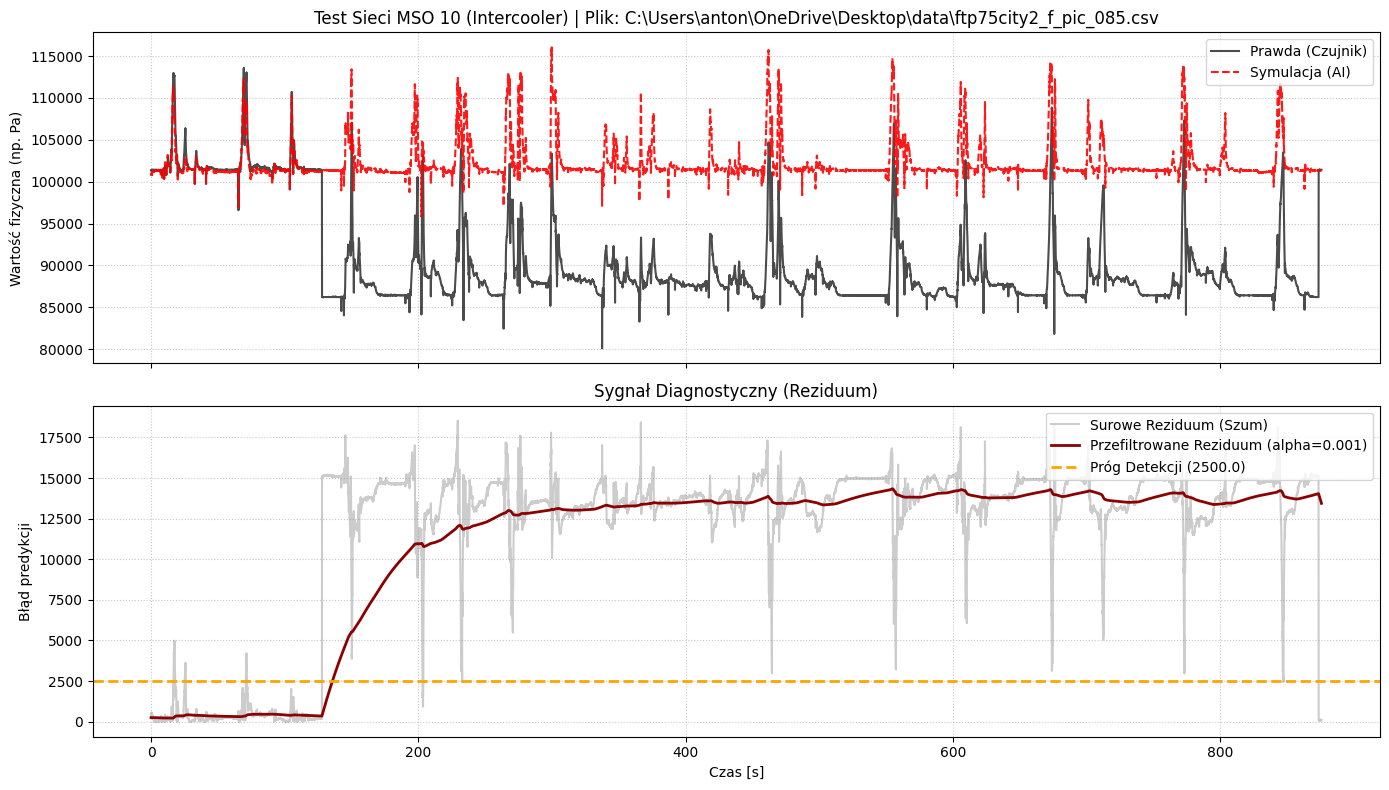

Średni błąd bezwzględny (MAE po rozgrzewce): 11762.0625
Maksymalny błąd przefiltrowany (po rozgrzewce): 14337.1475


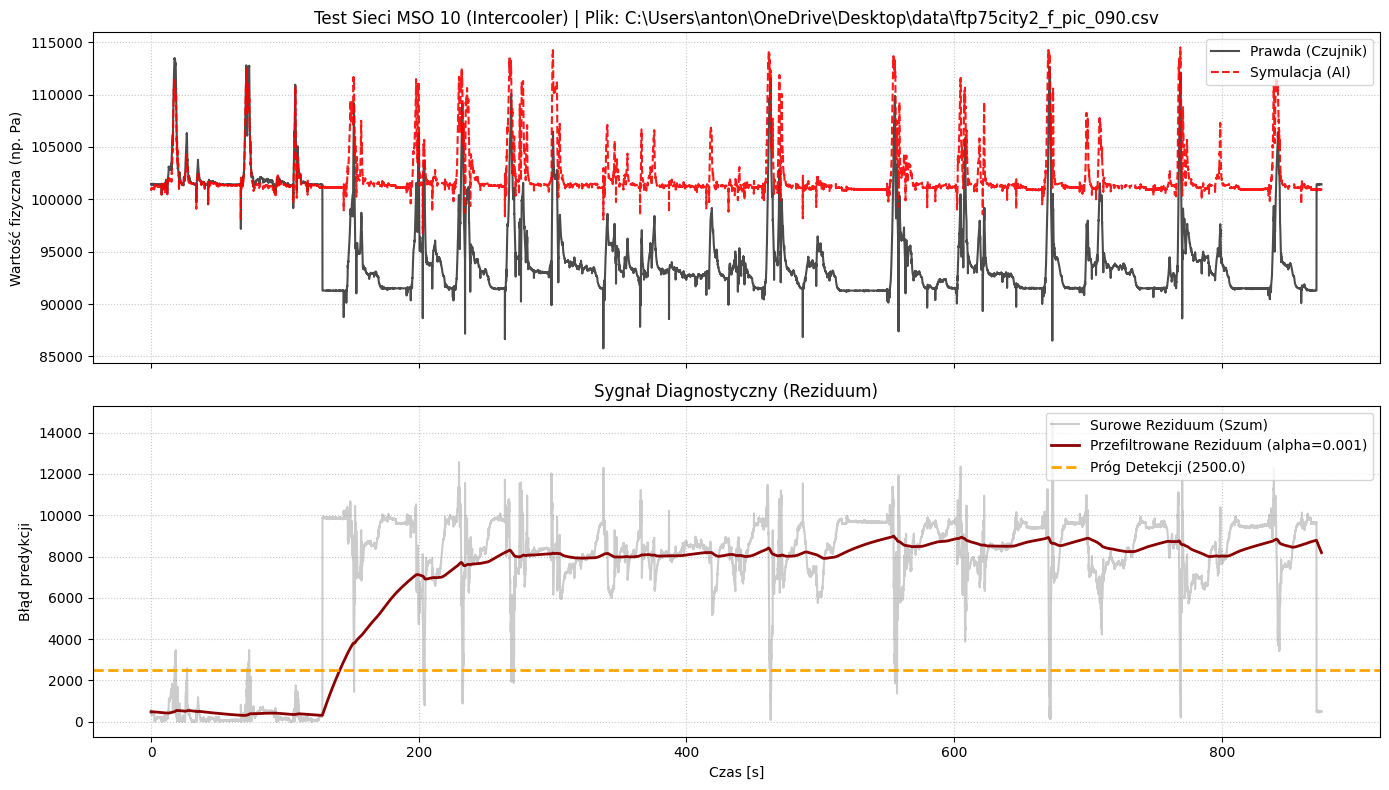

Średni błąd bezwzględny (MAE po rozgrzewce): 7245.4785
Maksymalny błąd przefiltrowany (po rozgrzewce): 8993.1924


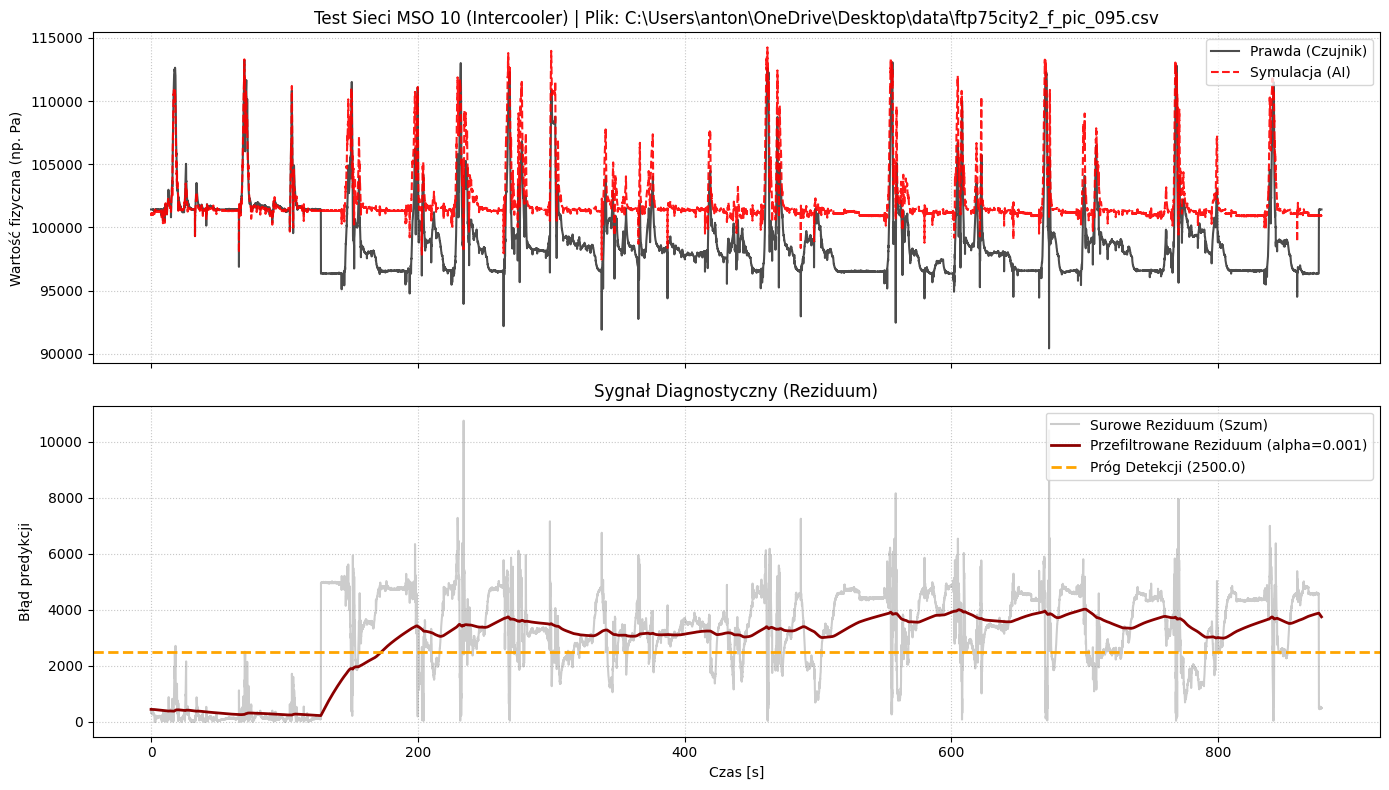

Średni błąd bezwzględny (MAE po rozgrzewce): 3072.8469
Maksymalny błąd przefiltrowany (po rozgrzewce): 4020.1917


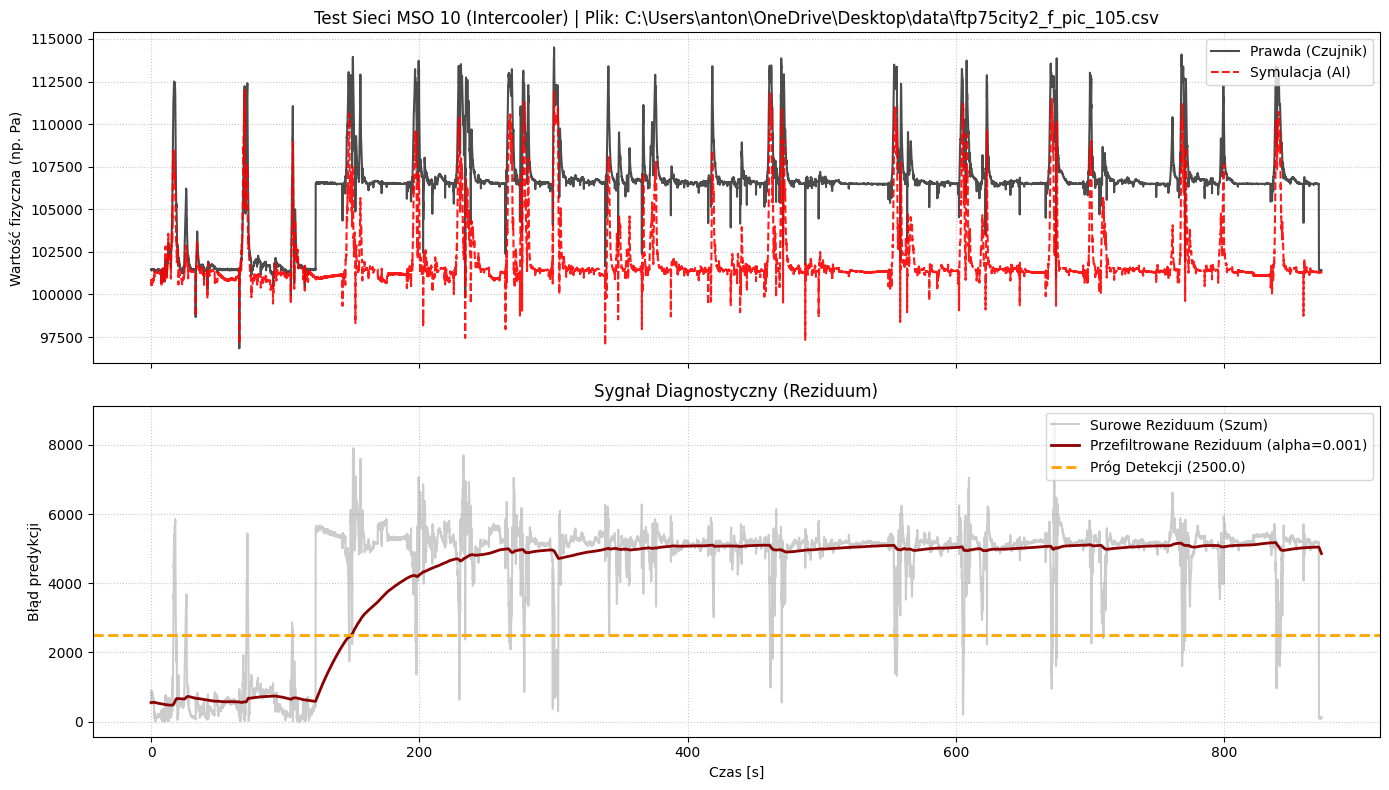

Średni błąd bezwzględny (MAE po rozgrzewce): 4441.4712
Maksymalny błąd przefiltrowany (po rozgrzewce): 5175.7700


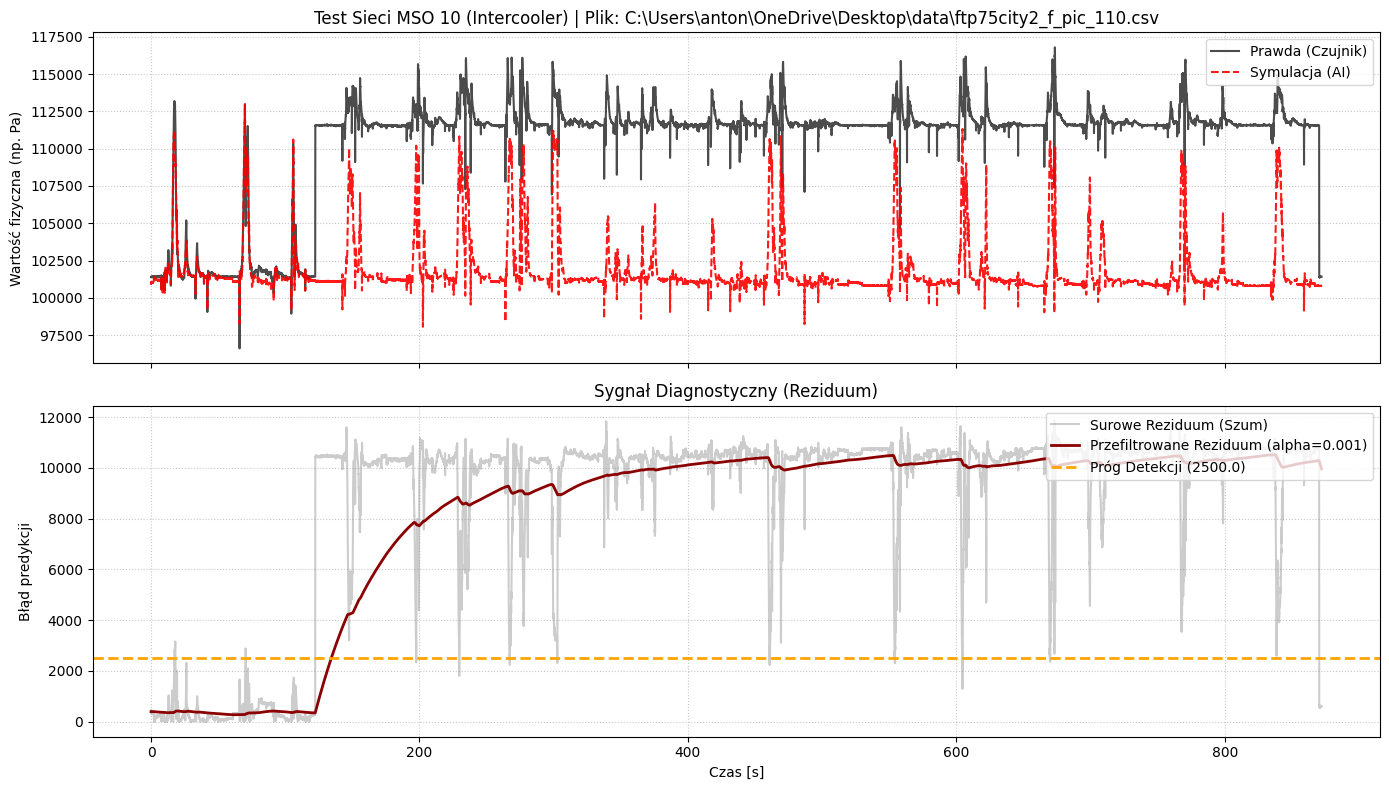

Średni błąd bezwzględny (MAE po rozgrzewce): 8709.8896
Maksymalny błąd przefiltrowany (po rozgrzewce): 10513.5508


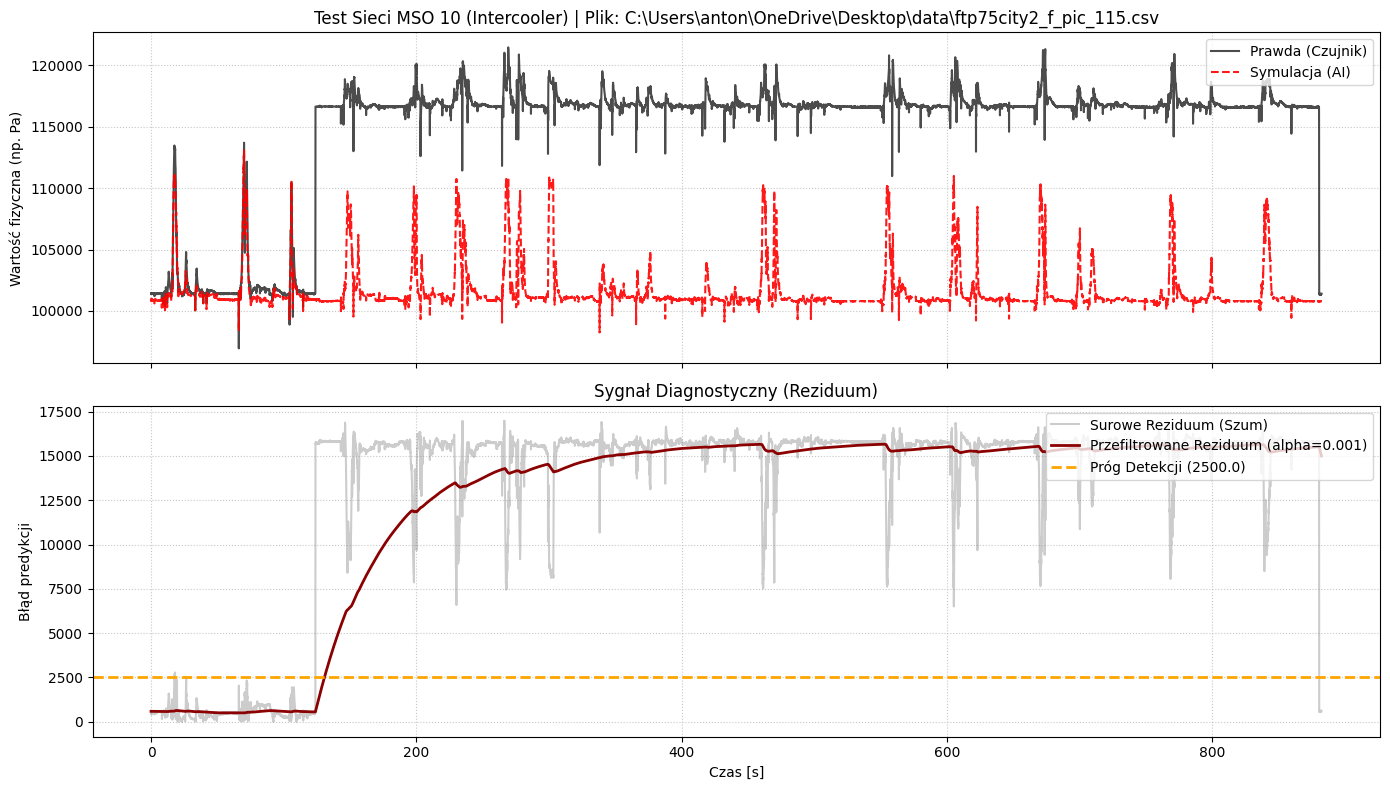

Średni błąd bezwzględny (MAE po rozgrzewce): 13235.5801
Maksymalny błąd przefiltrowany (po rozgrzewce): 15668.7090


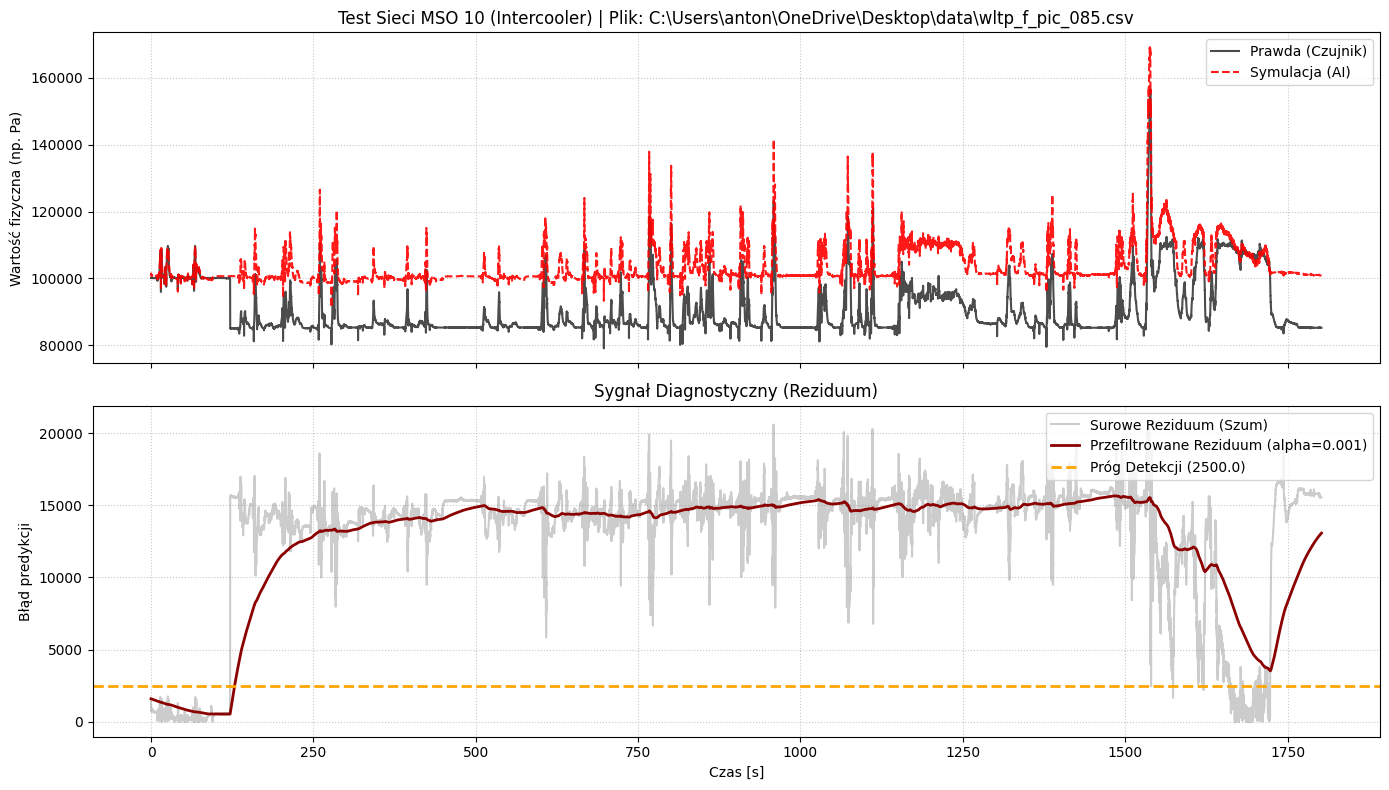

Średni błąd bezwzględny (MAE po rozgrzewce): 12937.0391
Maksymalny błąd przefiltrowany (po rozgrzewce): 15663.4023


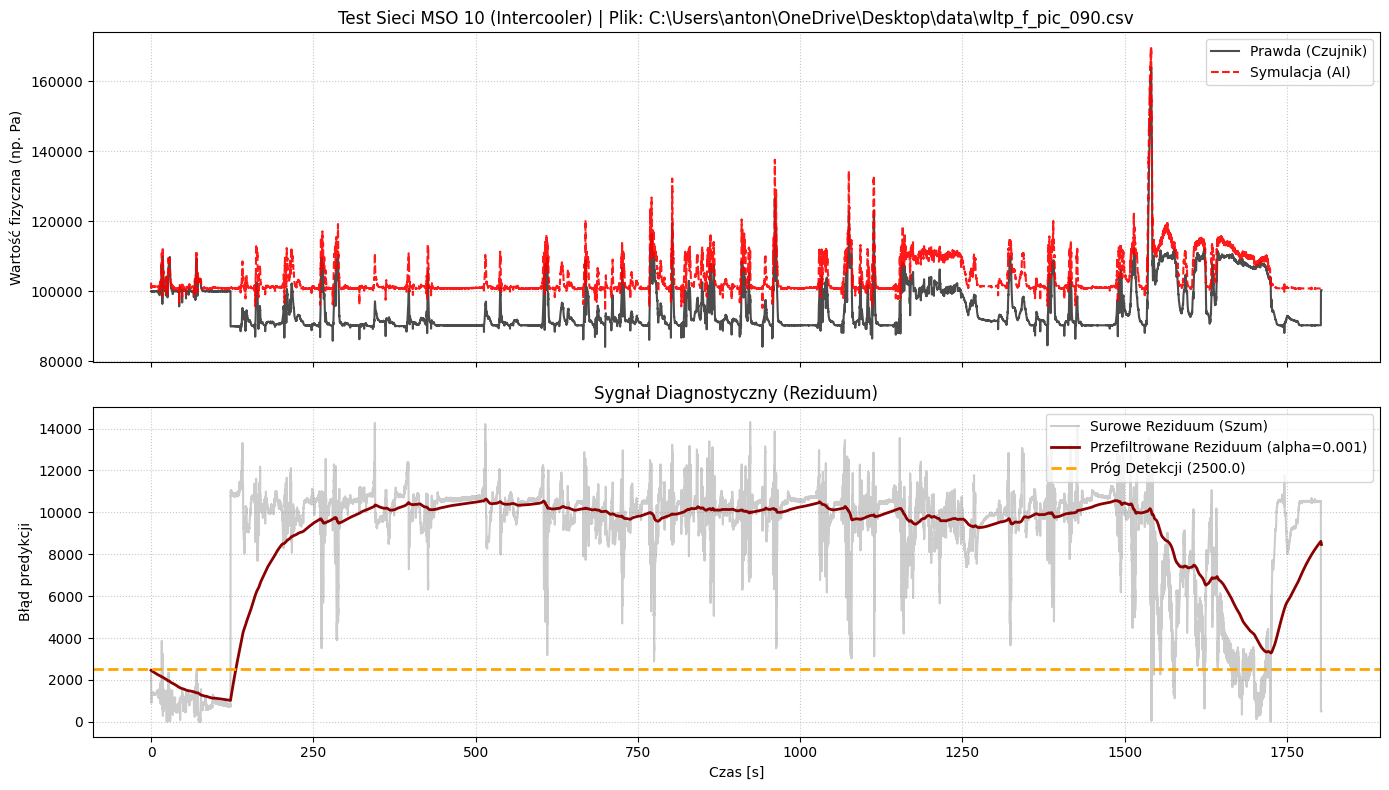

Średni błąd bezwzględny (MAE po rozgrzewce): 8881.4873
Maksymalny błąd przefiltrowany (po rozgrzewce): 10638.7812


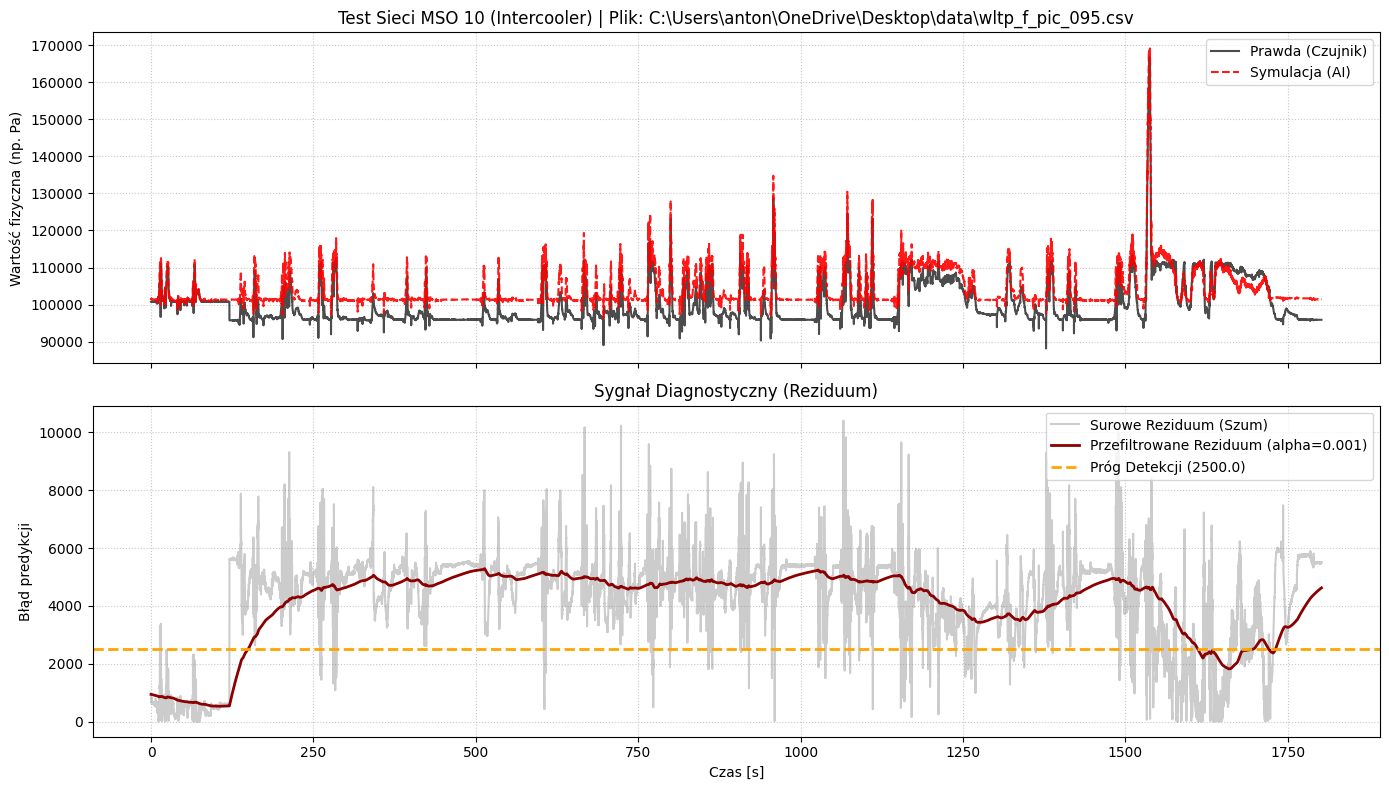

Średni błąd bezwzględny (MAE po rozgrzewce): 4180.0107
Maksymalny błąd przefiltrowany (po rozgrzewce): 5286.5220


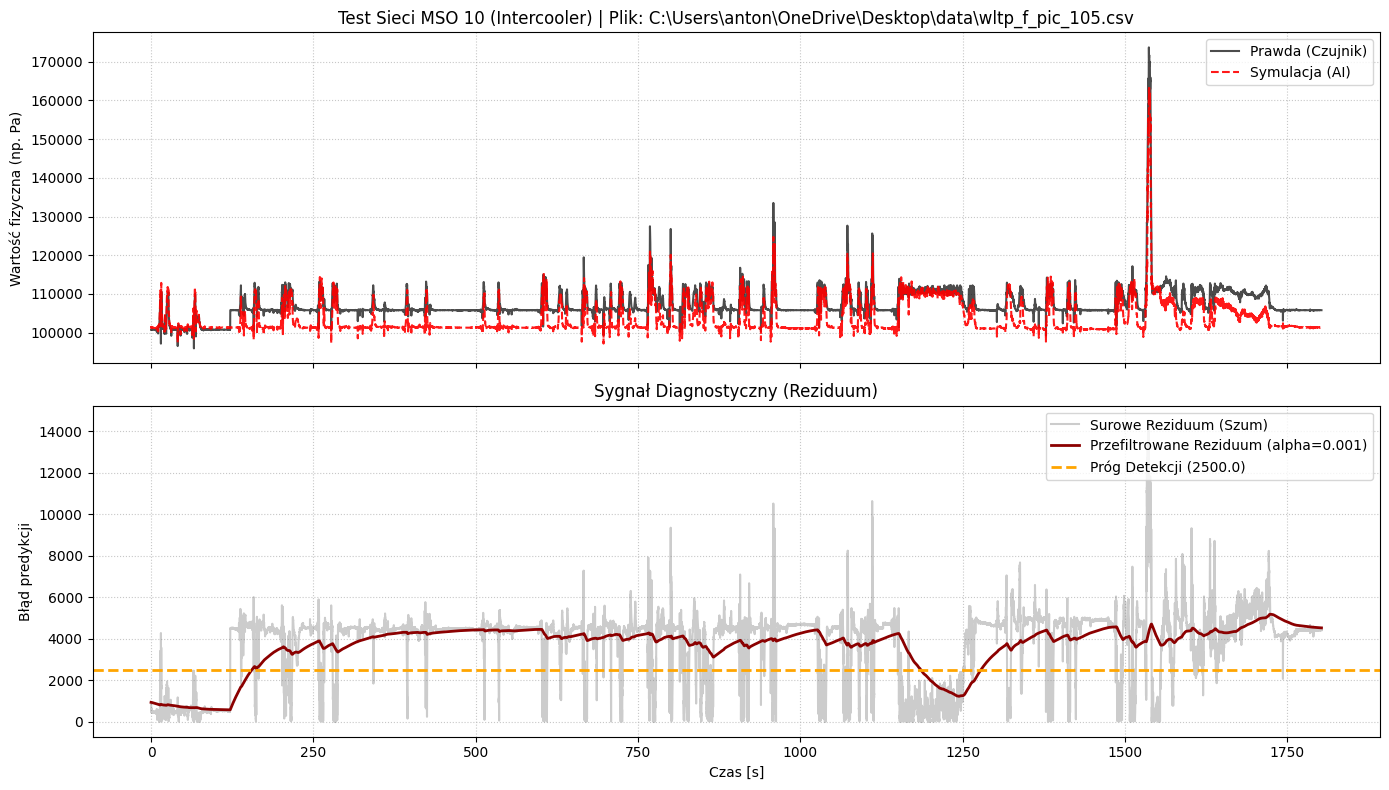

Średni błąd bezwzględny (MAE po rozgrzewce): 3751.6584
Maksymalny błąd przefiltrowany (po rozgrzewce): 5182.0698


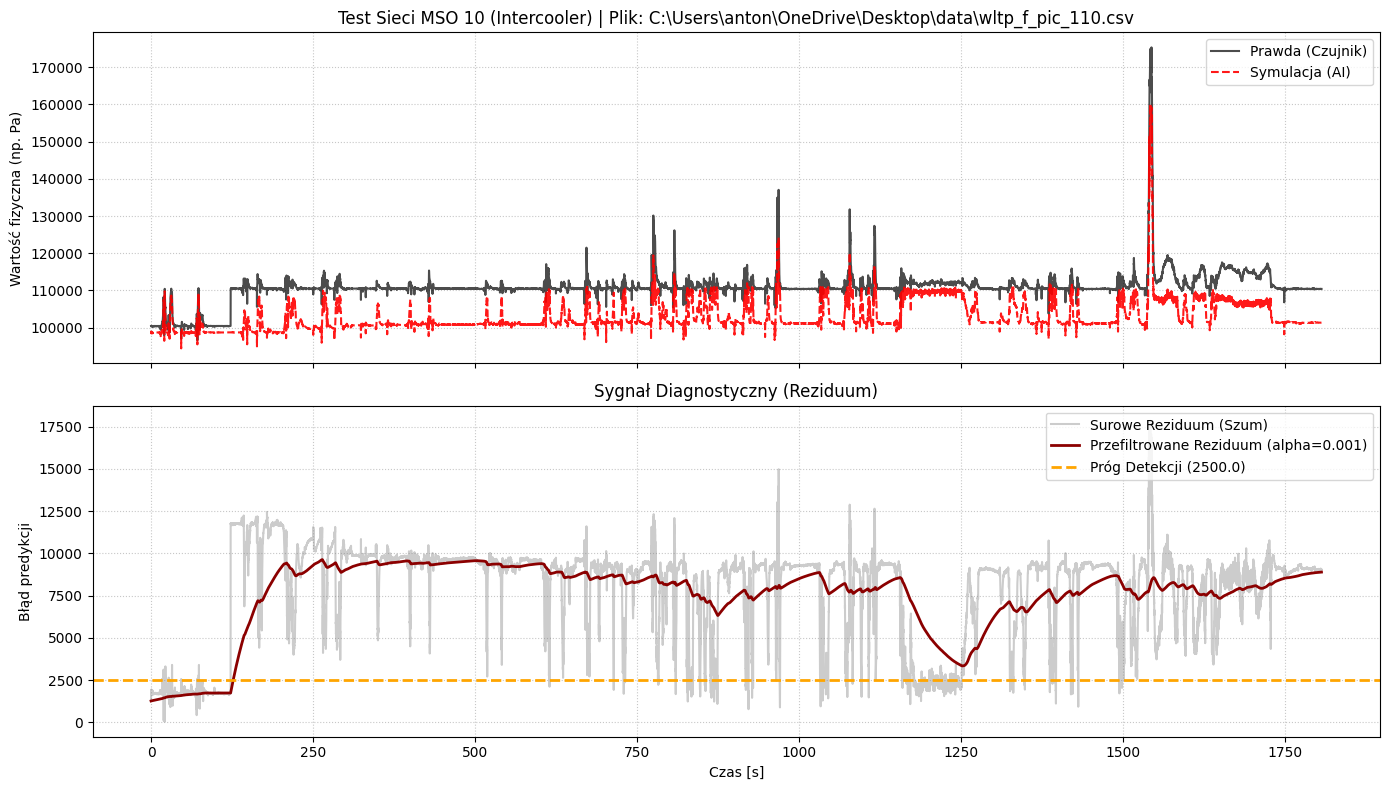

Średni błąd bezwzględny (MAE po rozgrzewce): 7773.6387
Maksymalny błąd przefiltrowany (po rozgrzewce): 9640.2197


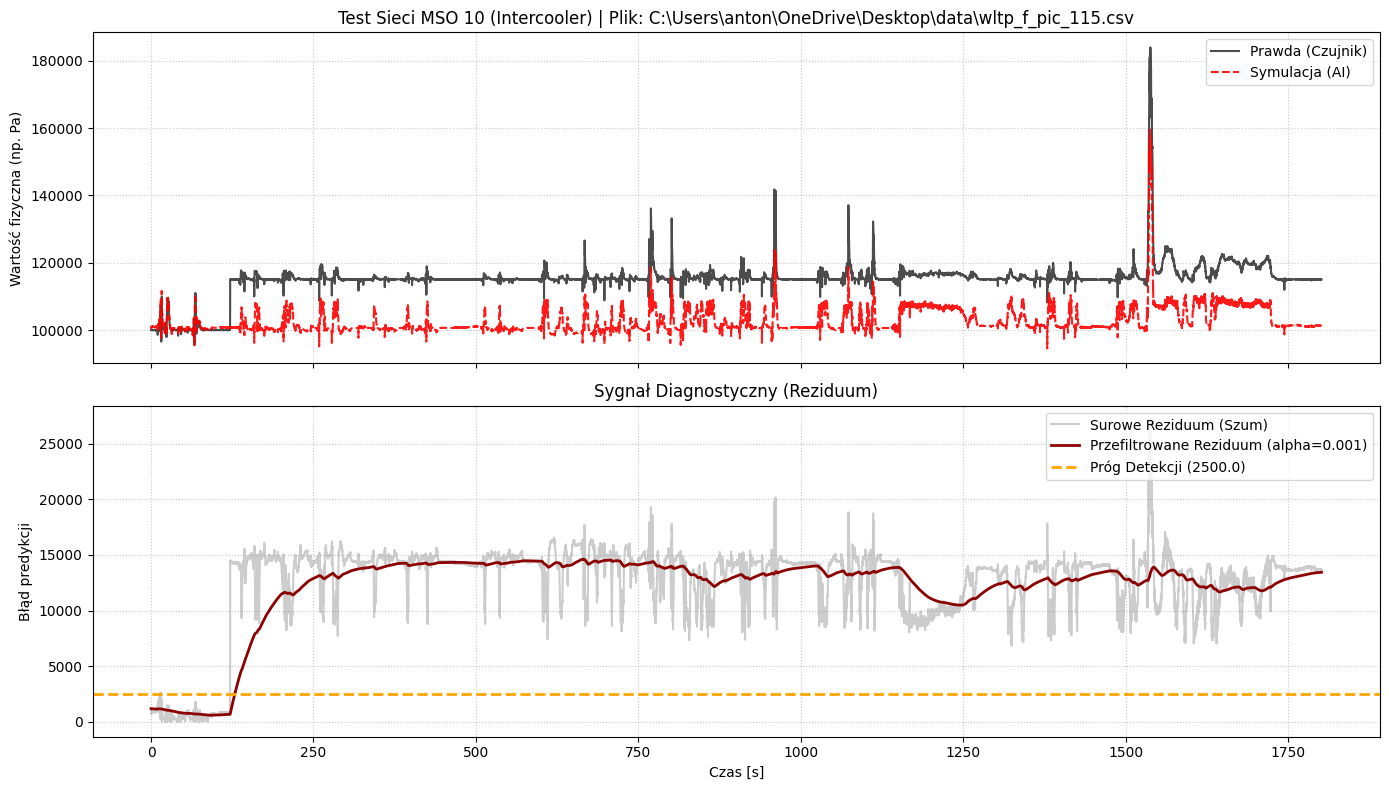

Średni błąd bezwzględny (MAE po rozgrzewce): 12425.7812
Maksymalny błąd przefiltrowany (po rozgrzewce): 14627.5732


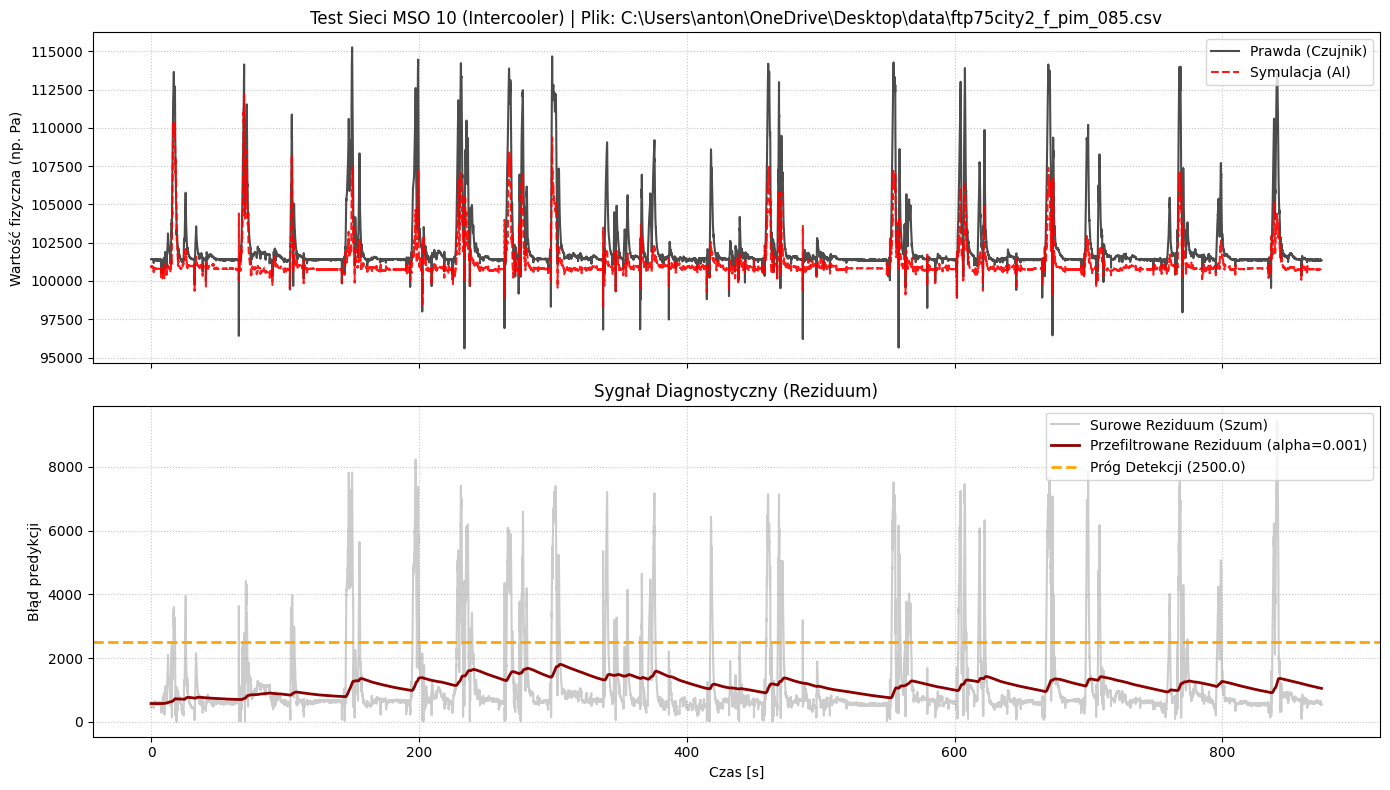

Średni błąd bezwzględny (MAE po rozgrzewce): 1173.6522
Maksymalny błąd przefiltrowany (po rozgrzewce): 1801.1573


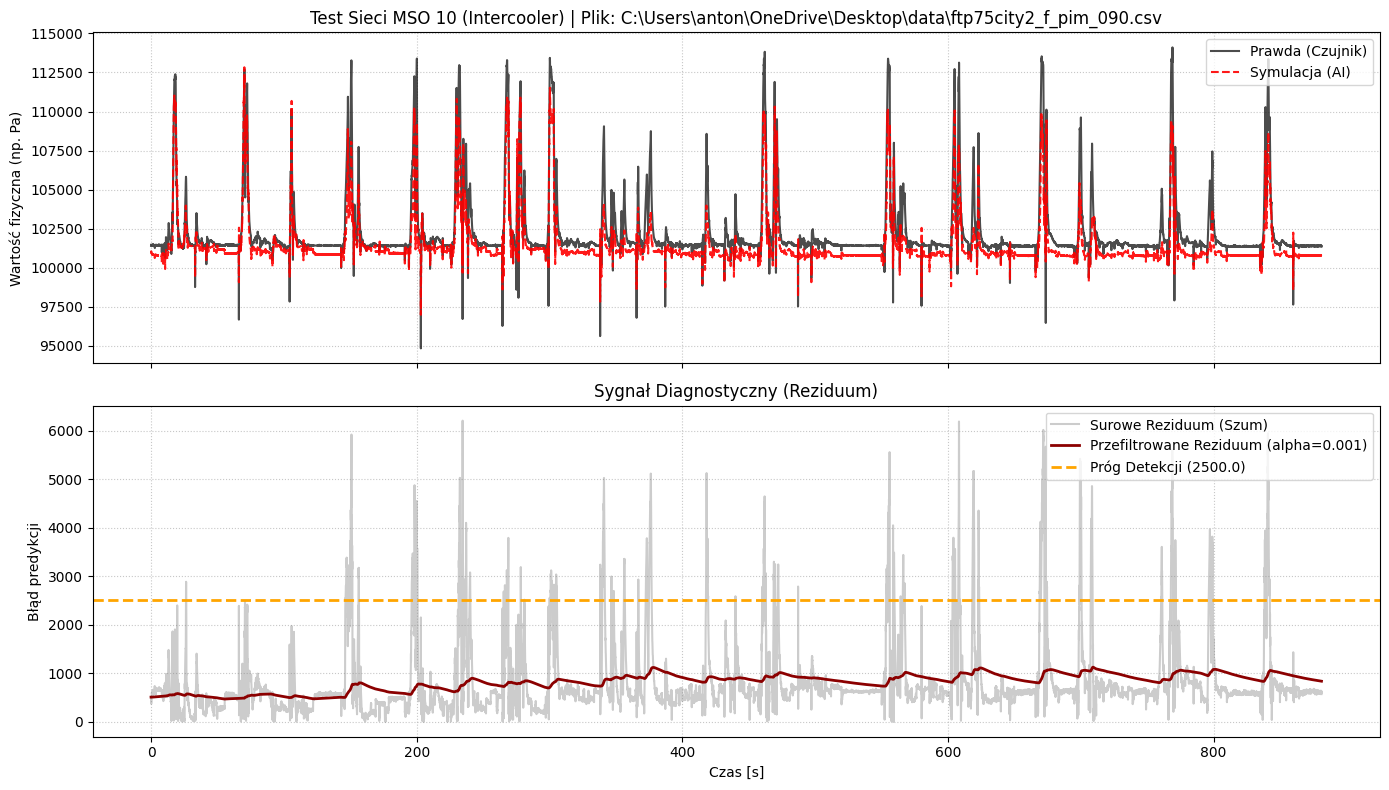

Średni błąd bezwzględny (MAE po rozgrzewce): 836.7957
Maksymalny błąd przefiltrowany (po rozgrzewce): 1124.3867


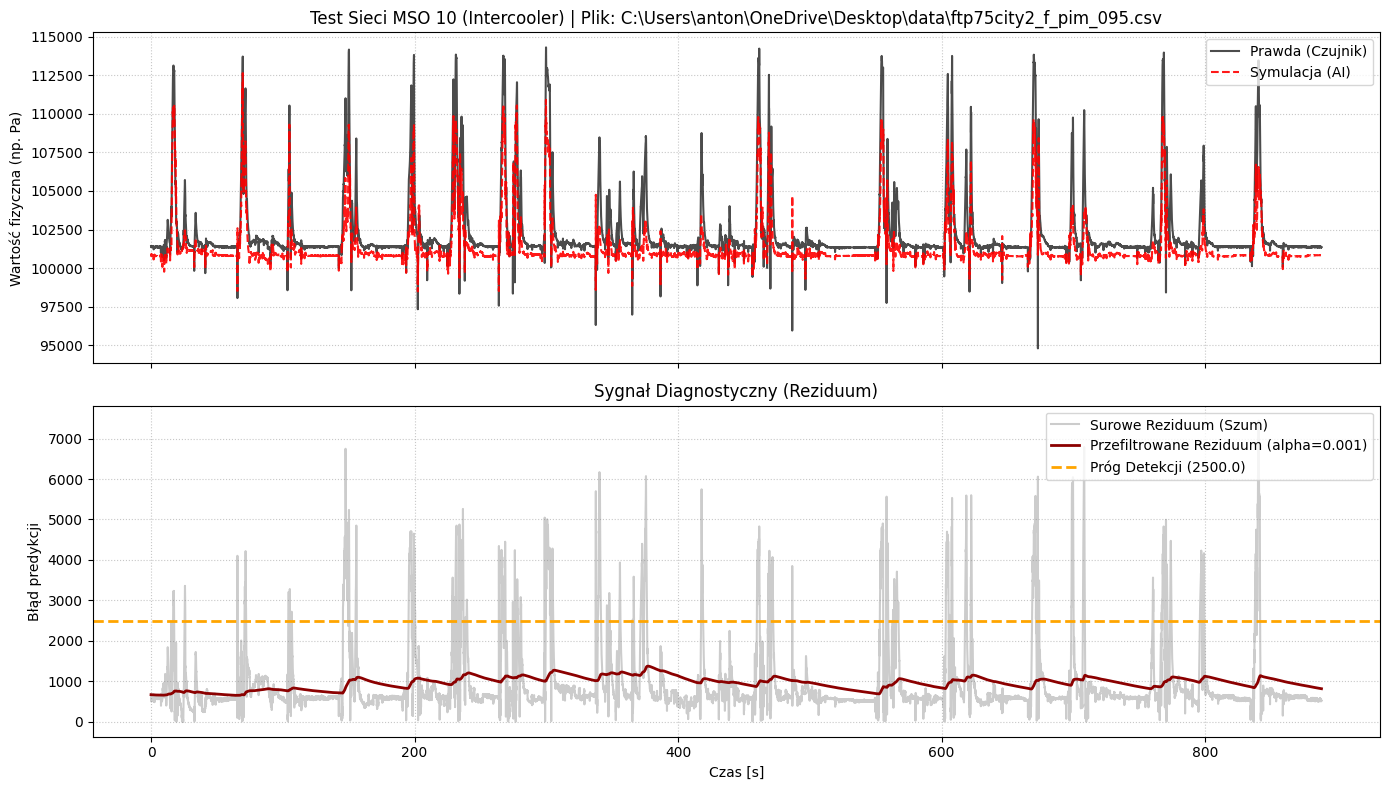

Średni błąd bezwzględny (MAE po rozgrzewce): 968.1826
Maksymalny błąd przefiltrowany (po rozgrzewce): 1373.8497


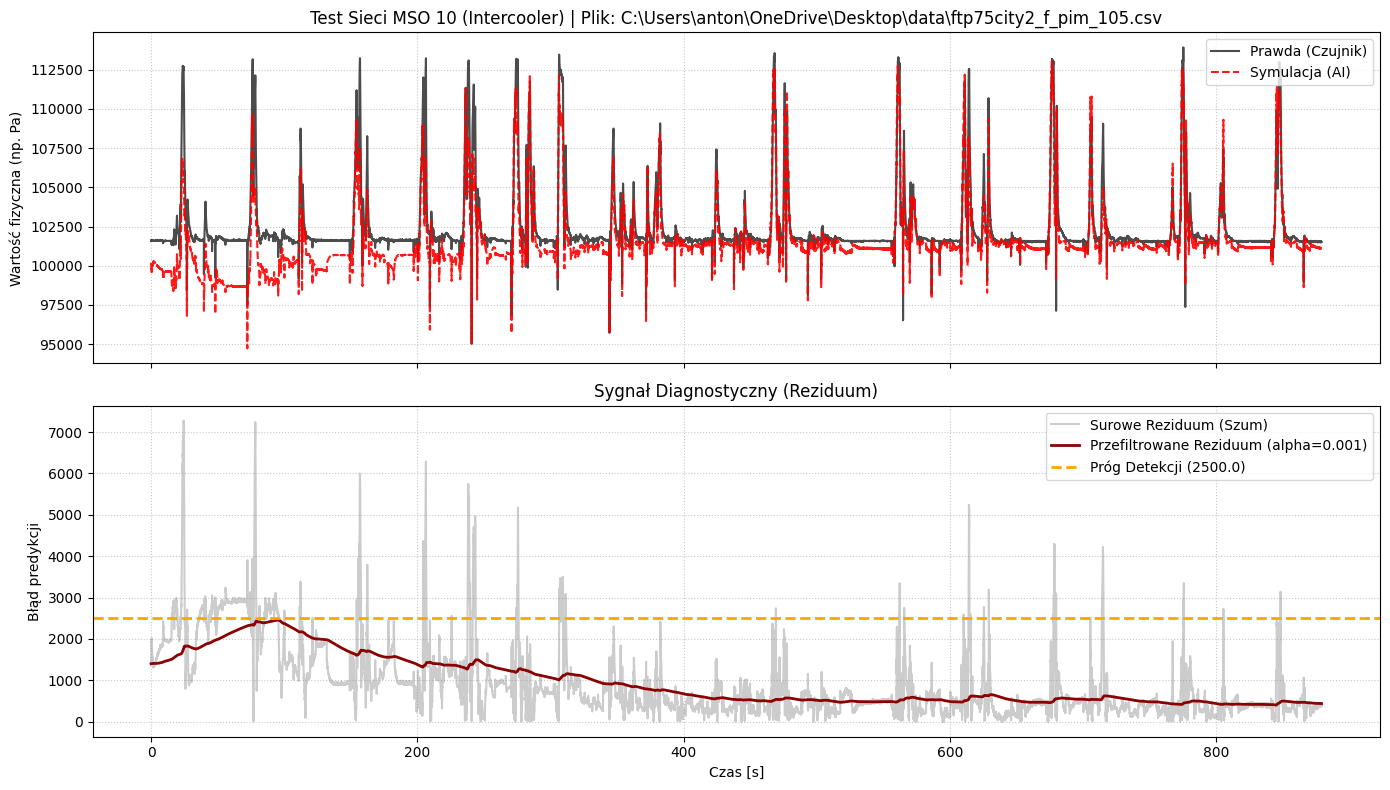

Średni błąd bezwzględny (MAE po rozgrzewce): 907.2419
Maksymalny błąd przefiltrowany (po rozgrzewce): 2459.9119


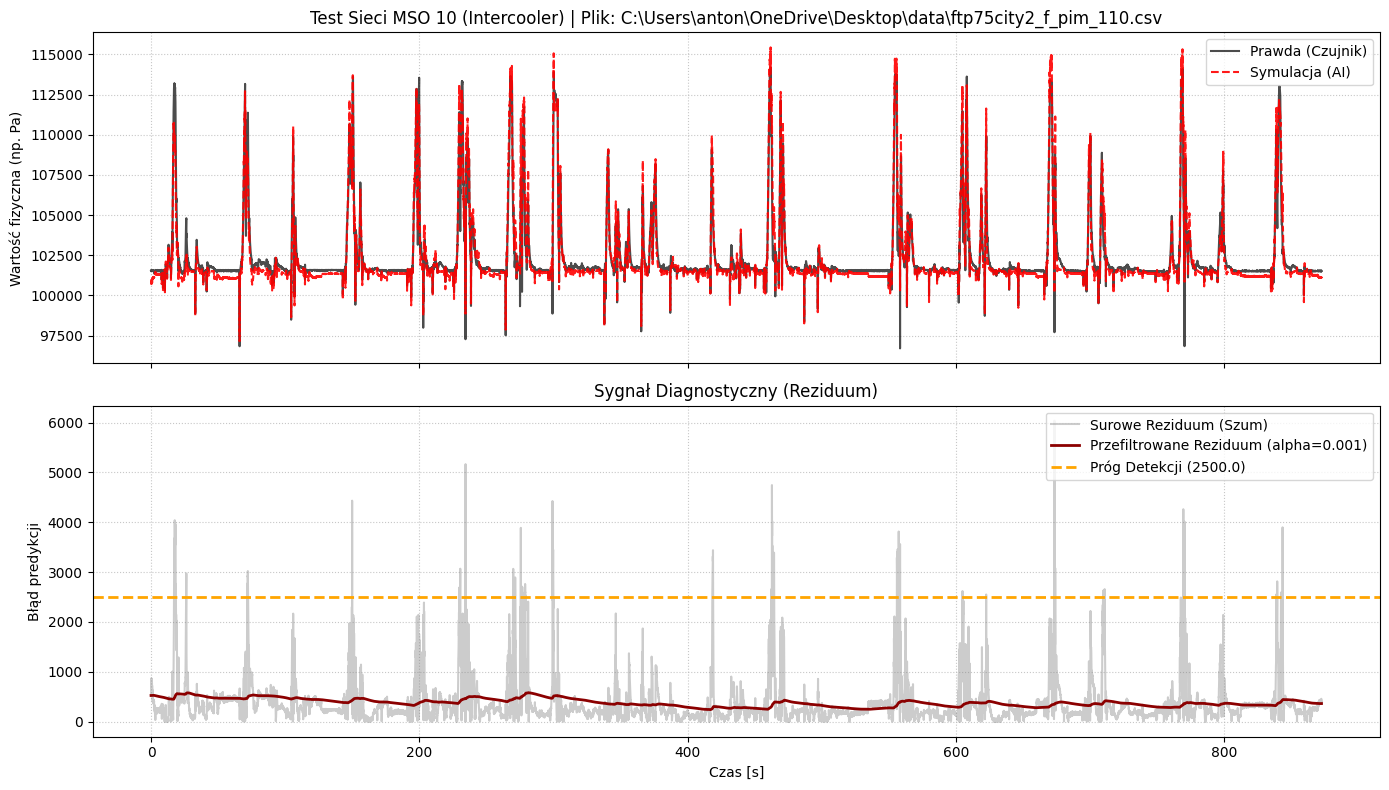

Średni błąd bezwzględny (MAE po rozgrzewce): 373.0059
Maksymalny błąd przefiltrowany (po rozgrzewce): 582.2594


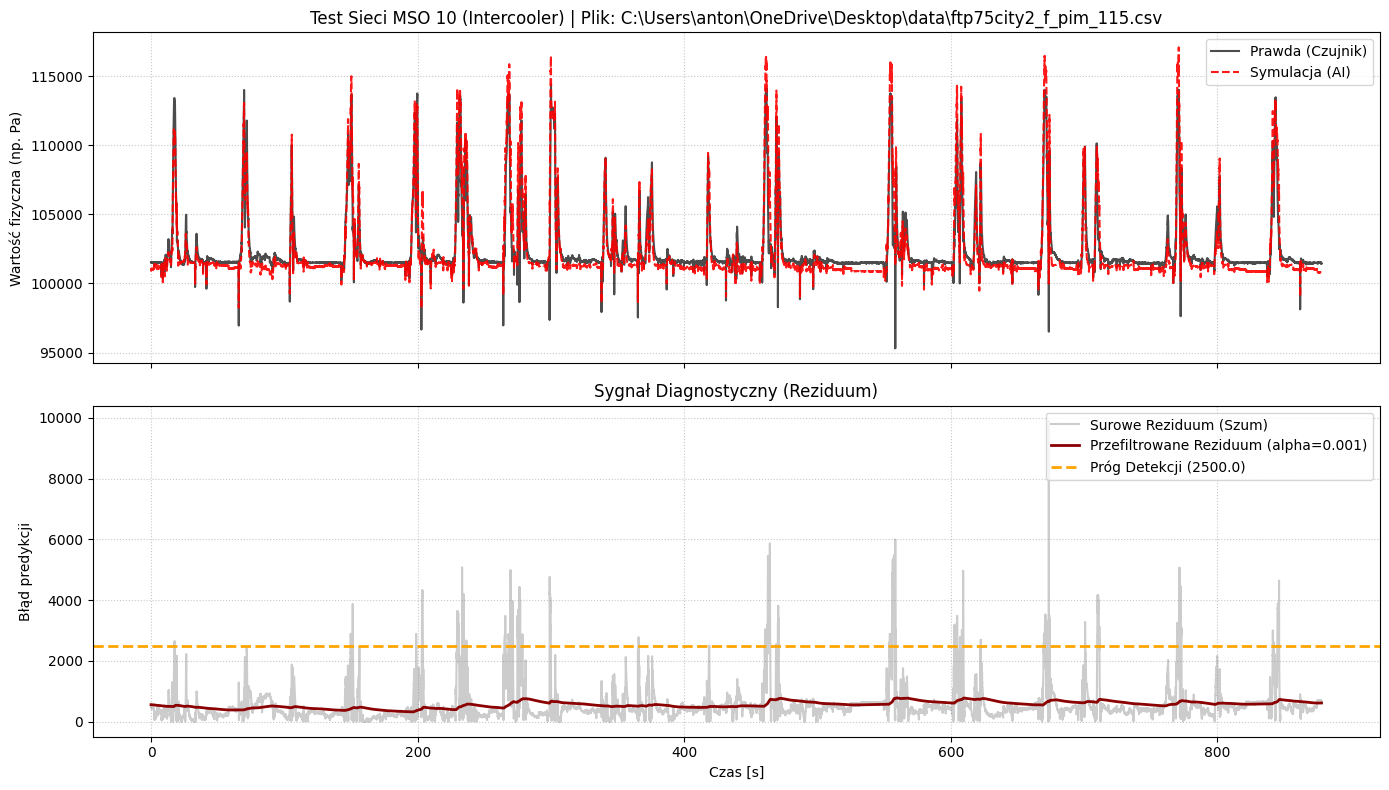

Średni błąd bezwzględny (MAE po rozgrzewce): 564.4899
Maksymalny błąd przefiltrowany (po rozgrzewce): 781.0099


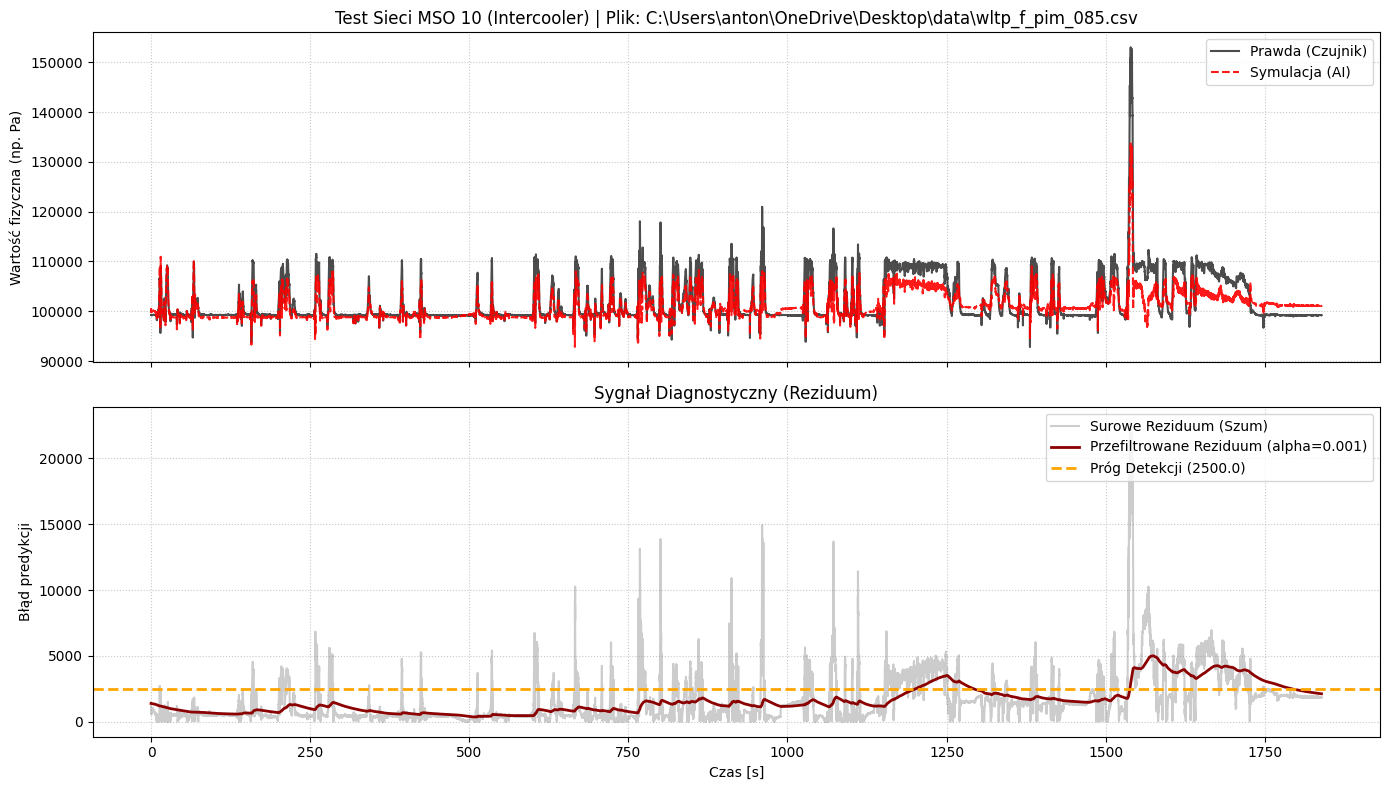

Średni błąd bezwzględny (MAE po rozgrzewce): 1663.5221
Maksymalny błąd przefiltrowany (po rozgrzewce): 5007.5229


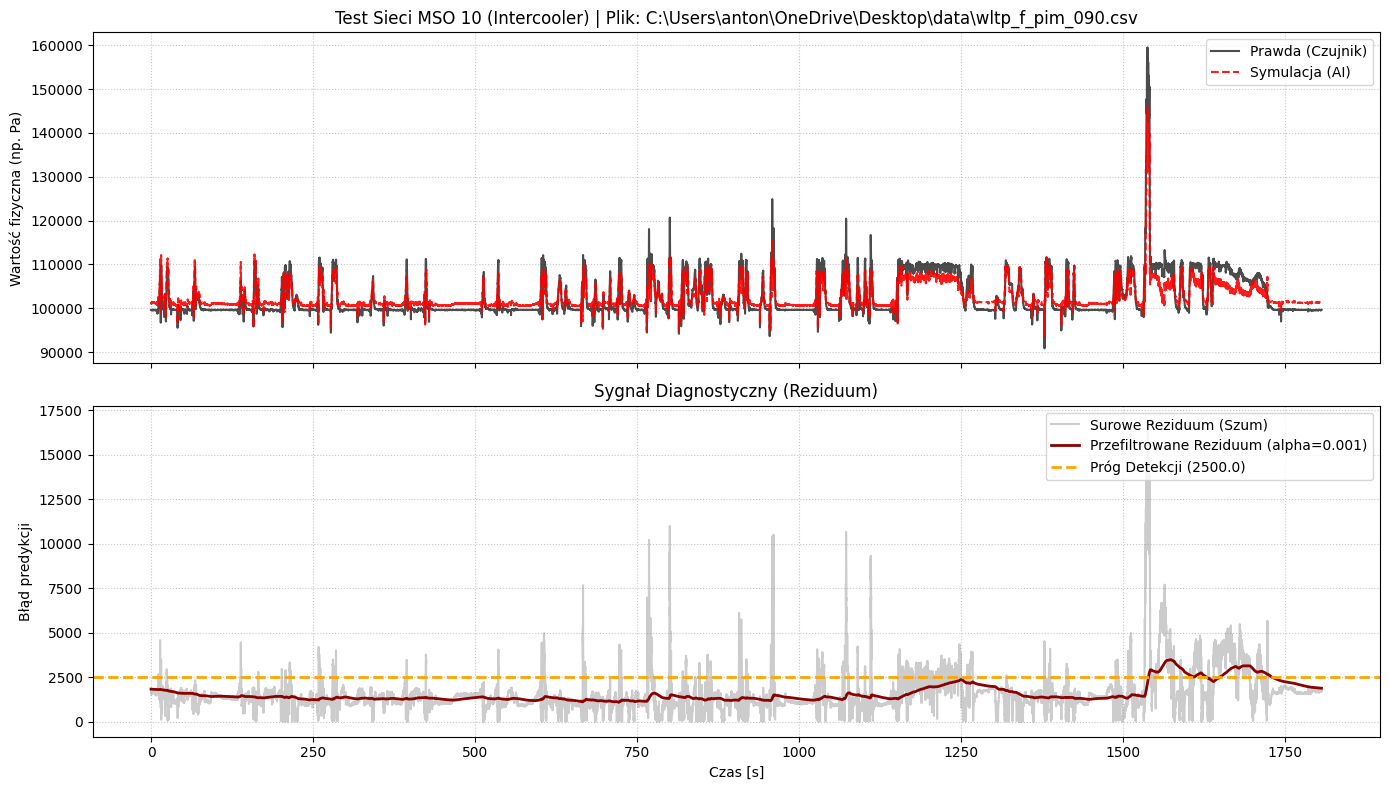

Średni błąd bezwzględny (MAE po rozgrzewce): 1596.4827
Maksymalny błąd przefiltrowany (po rozgrzewce): 3489.1077


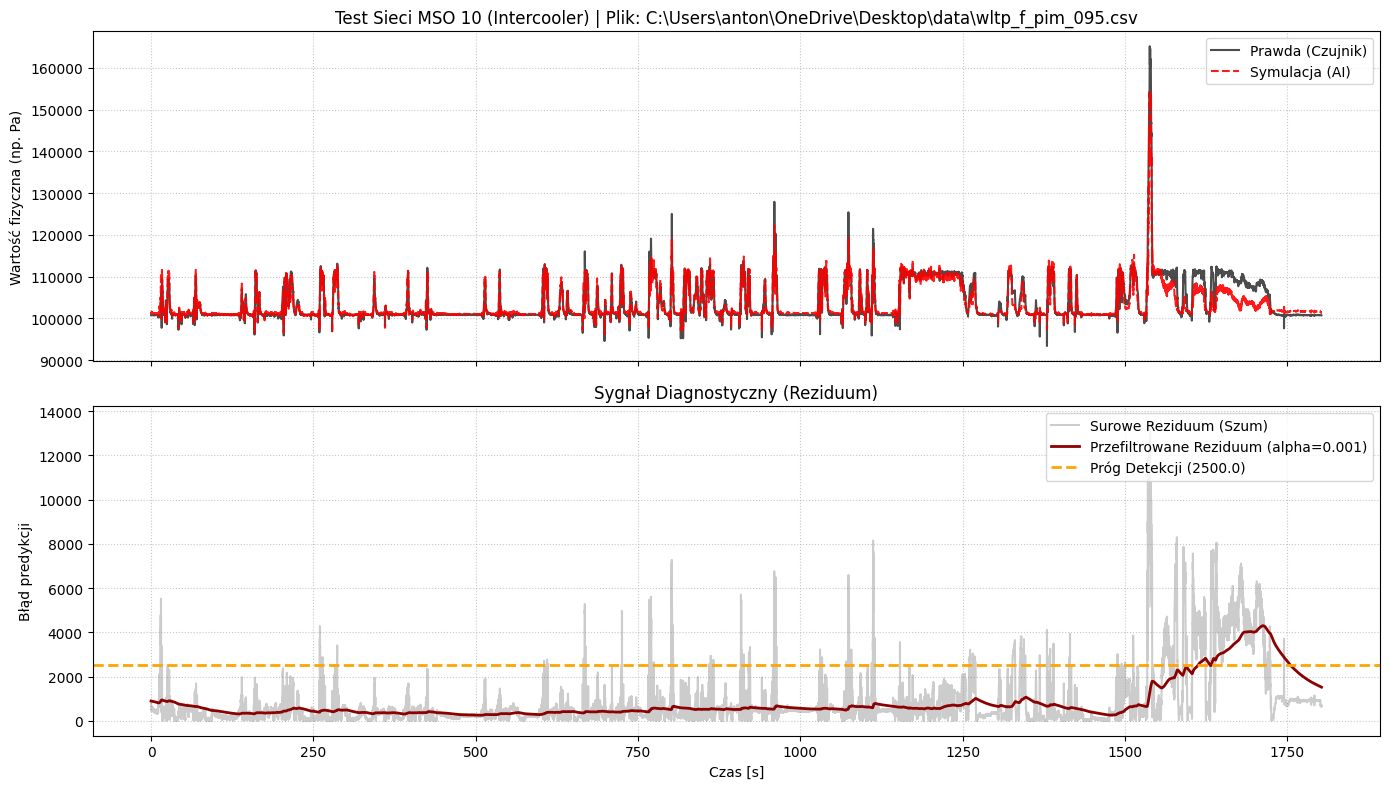

Średni błąd bezwzględny (MAE po rozgrzewce): 854.7230
Maksymalny błąd przefiltrowany (po rozgrzewce): 4297.6445


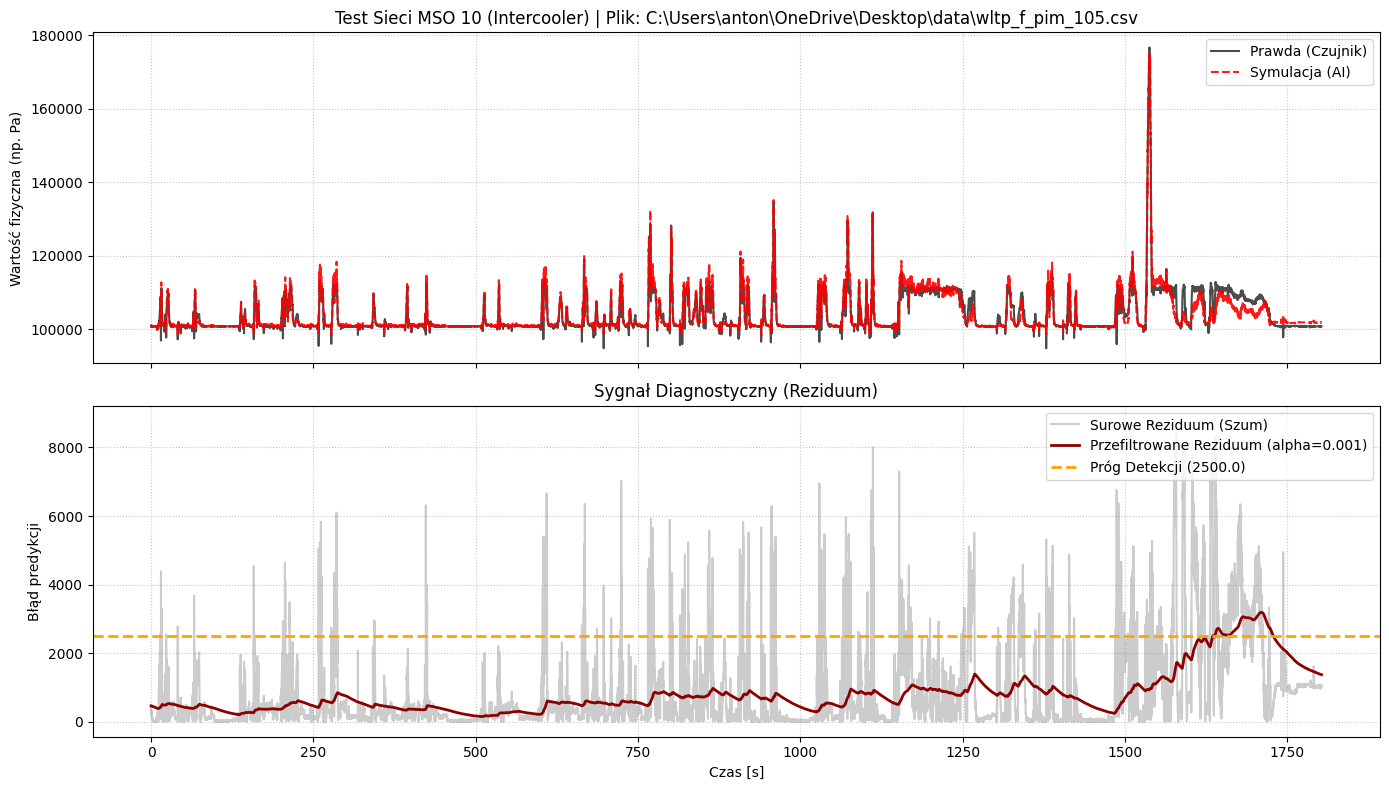

Średni błąd bezwzględny (MAE po rozgrzewce): 844.0207
Maksymalny błąd przefiltrowany (po rozgrzewce): 3190.2498


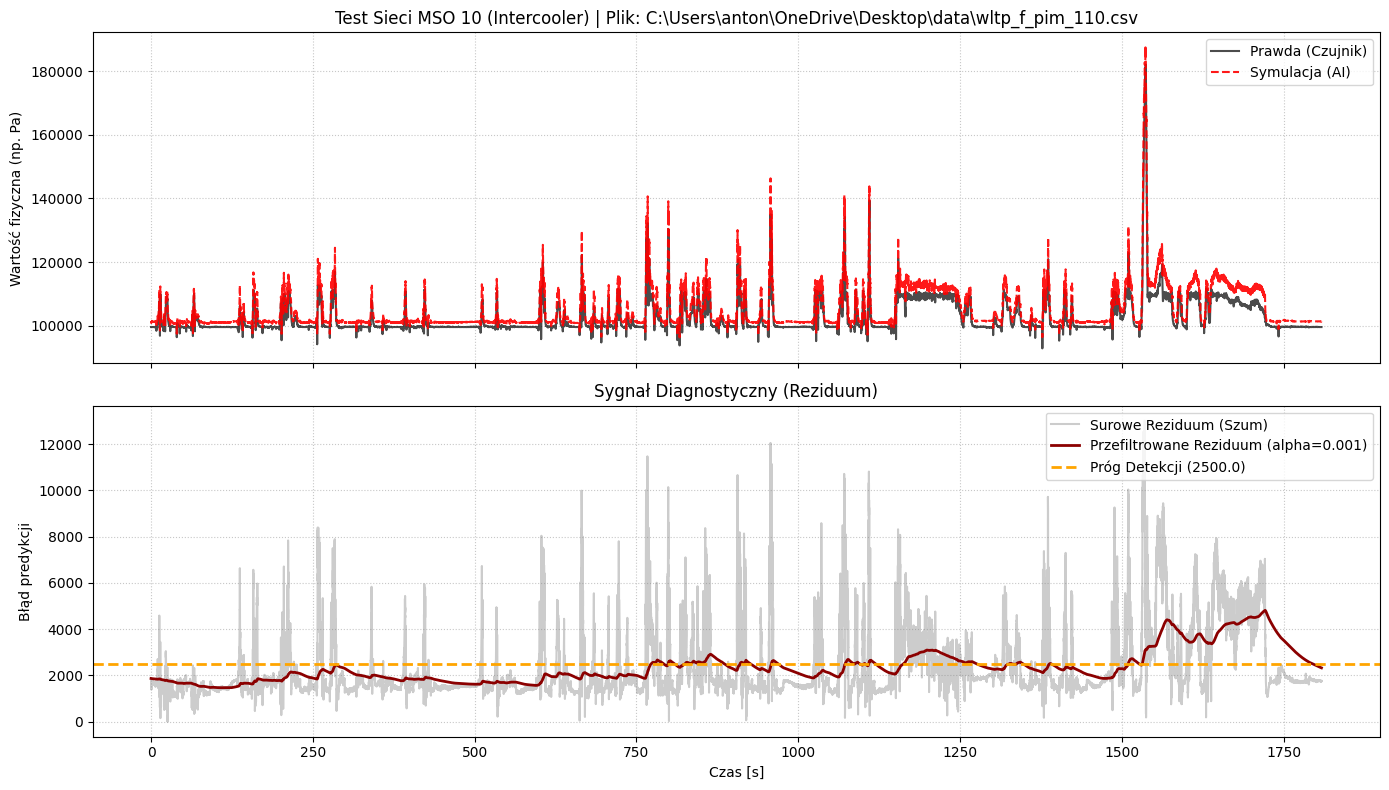

Średni błąd bezwzględny (MAE po rozgrzewce): 2378.0825
Maksymalny błąd przefiltrowany (po rozgrzewce): 4816.3882


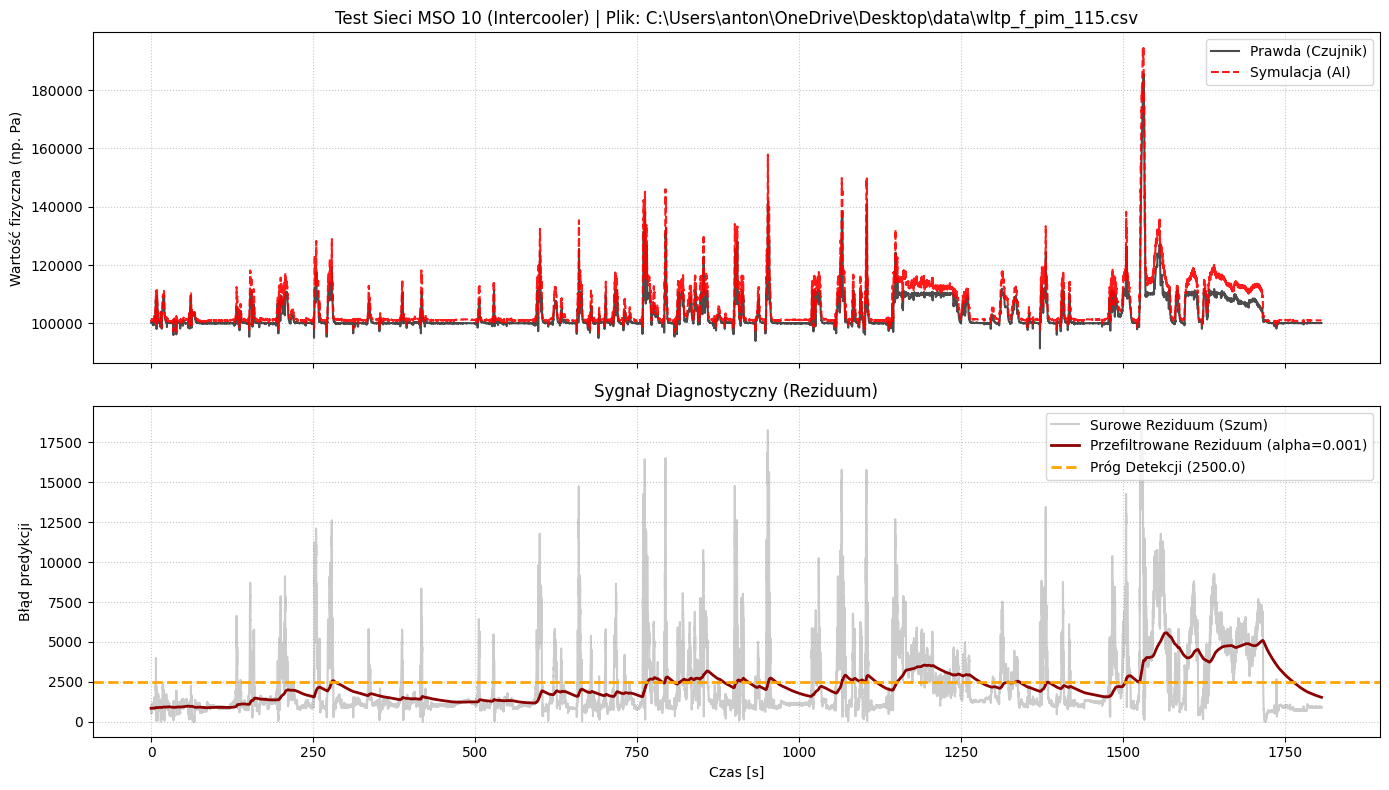

Średni błąd bezwzględny (MAE po rozgrzewce): 2283.9062
Maksymalny błąd przefiltrowany (po rozgrzewce): 5575.8145


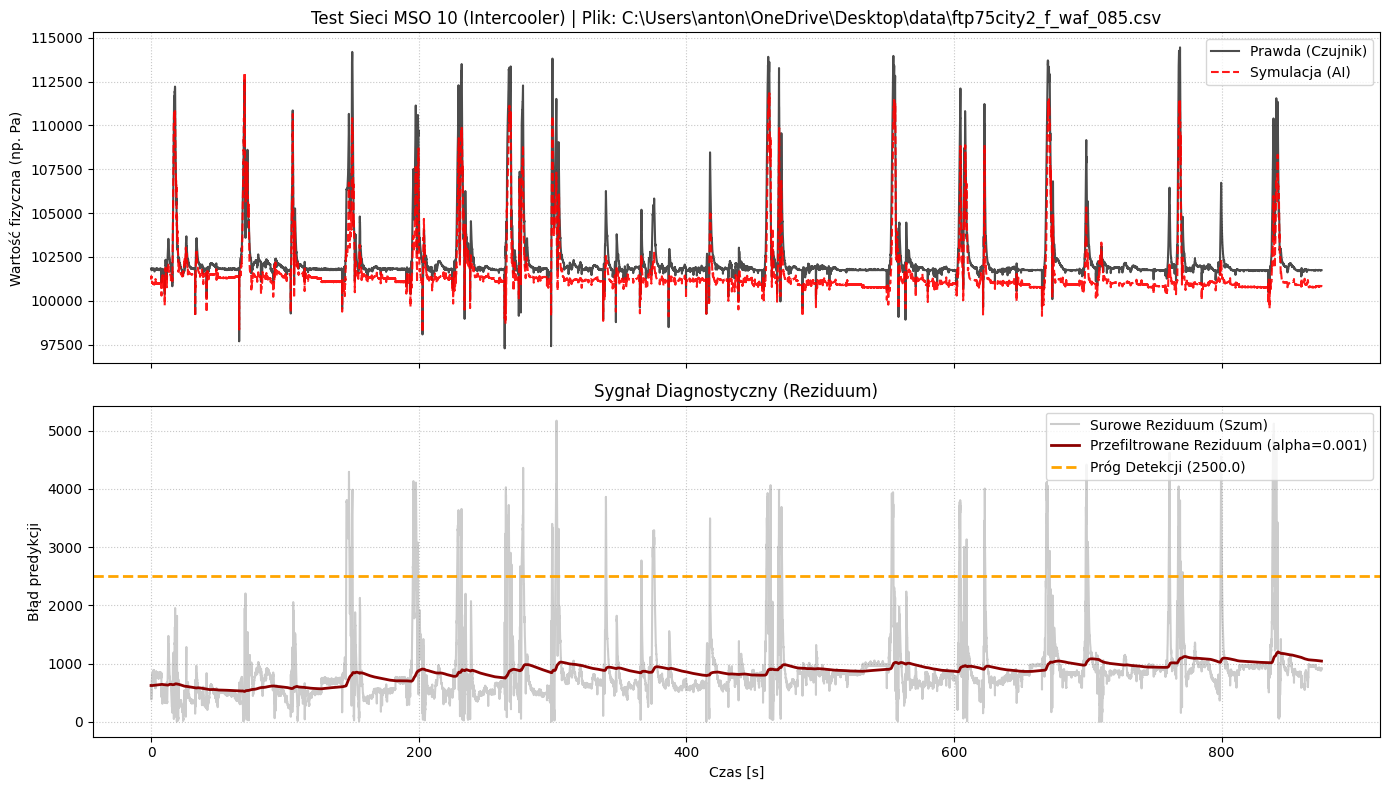

Średni błąd bezwzględny (MAE po rozgrzewce): 889.6990
Maksymalny błąd przefiltrowany (po rozgrzewce): 1200.8330


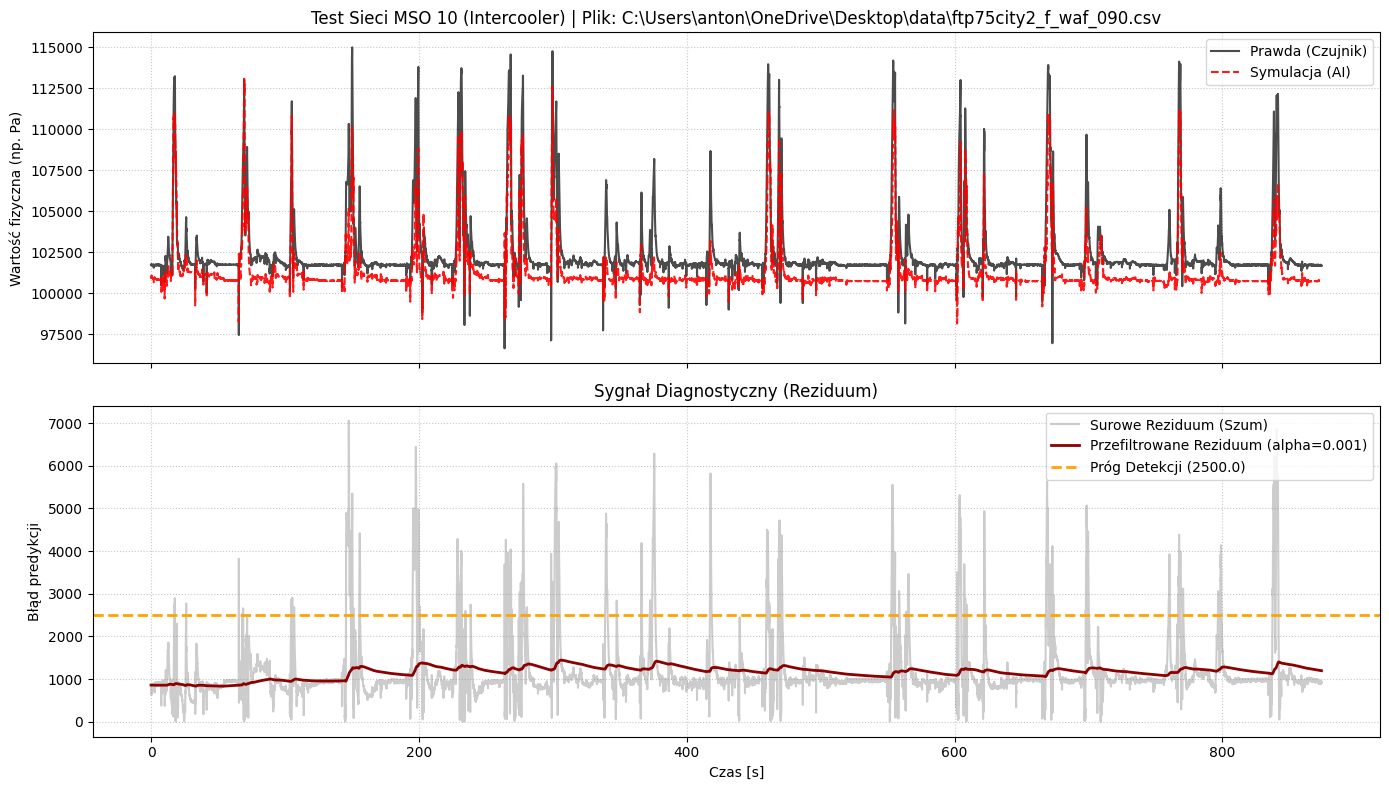

Średni błąd bezwzględny (MAE po rozgrzewce): 1180.8409
Maksymalny błąd przefiltrowany (po rozgrzewce): 1442.3401


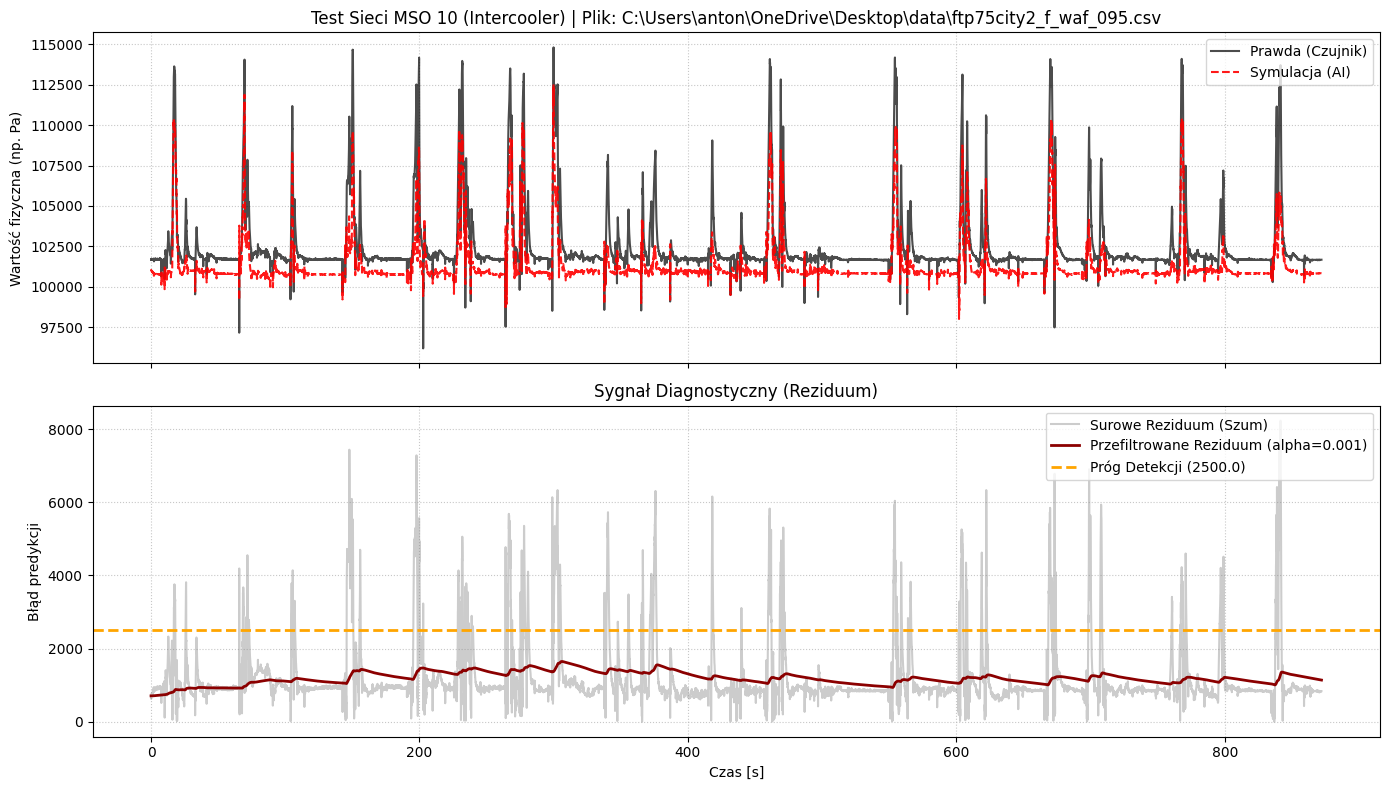

Średni błąd bezwzględny (MAE po rozgrzewce): 1217.1506
Maksymalny błąd przefiltrowany (po rozgrzewce): 1645.8162


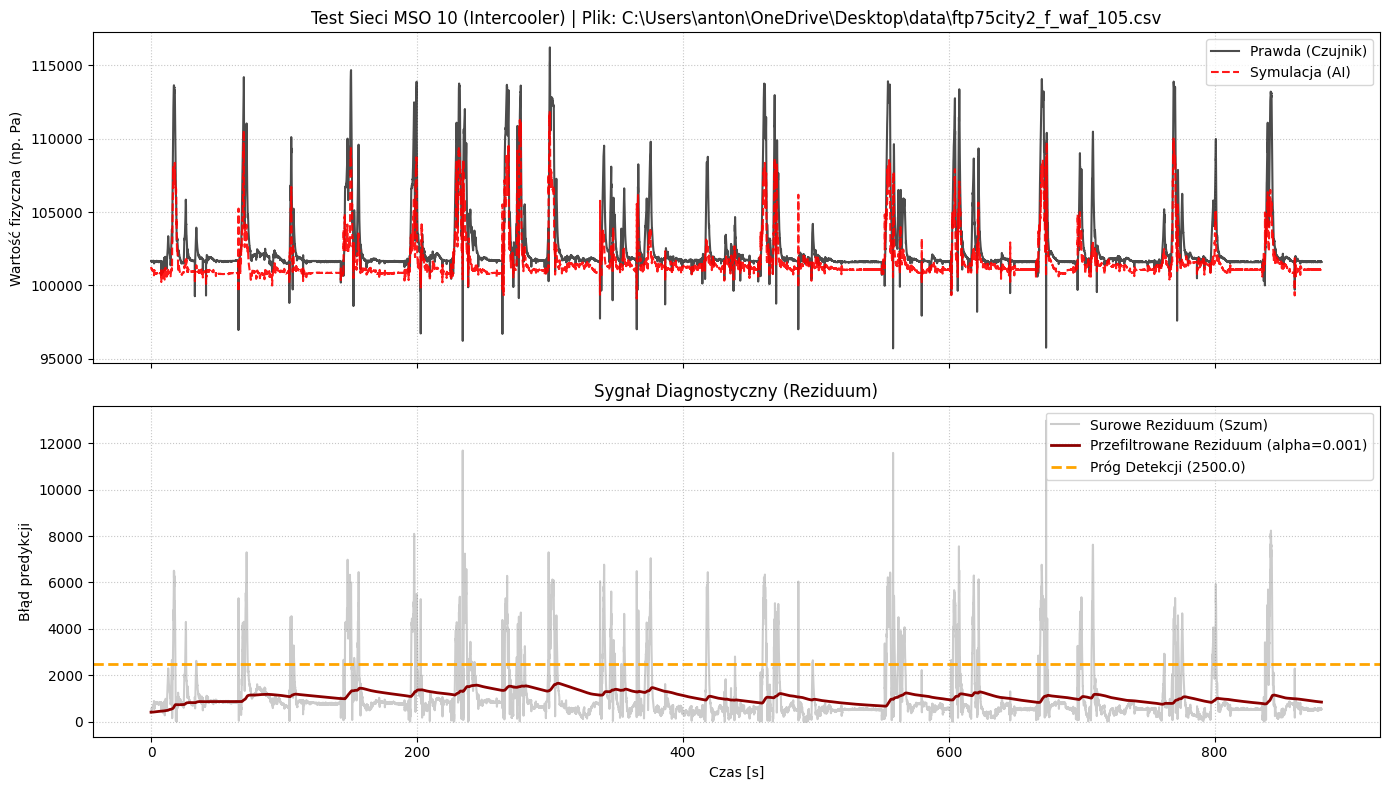

Średni błąd bezwzględny (MAE po rozgrzewce): 1097.3223
Maksymalny błąd przefiltrowany (po rozgrzewce): 1655.4447


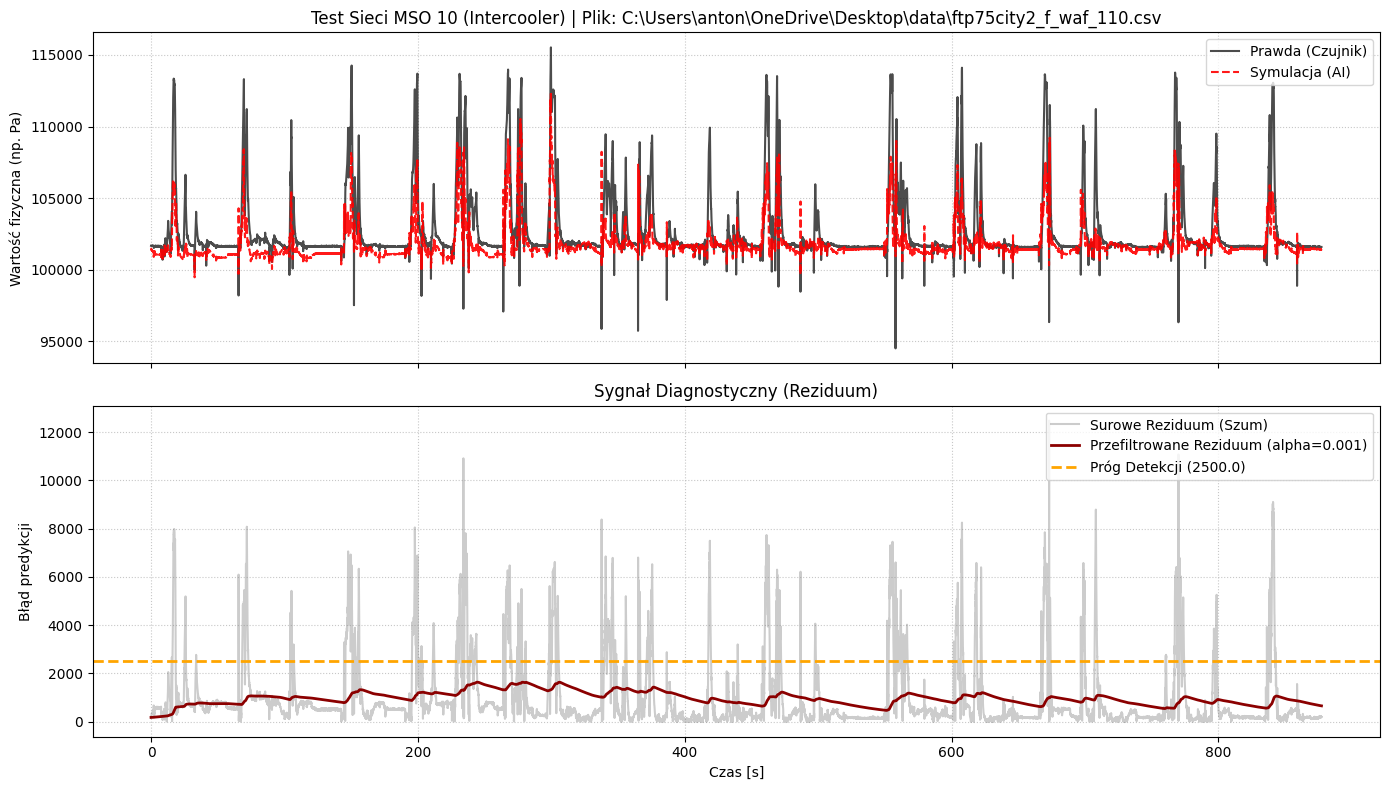

Średni błąd bezwzględny (MAE po rozgrzewce): 993.1703
Maksymalny błąd przefiltrowany (po rozgrzewce): 1637.7135


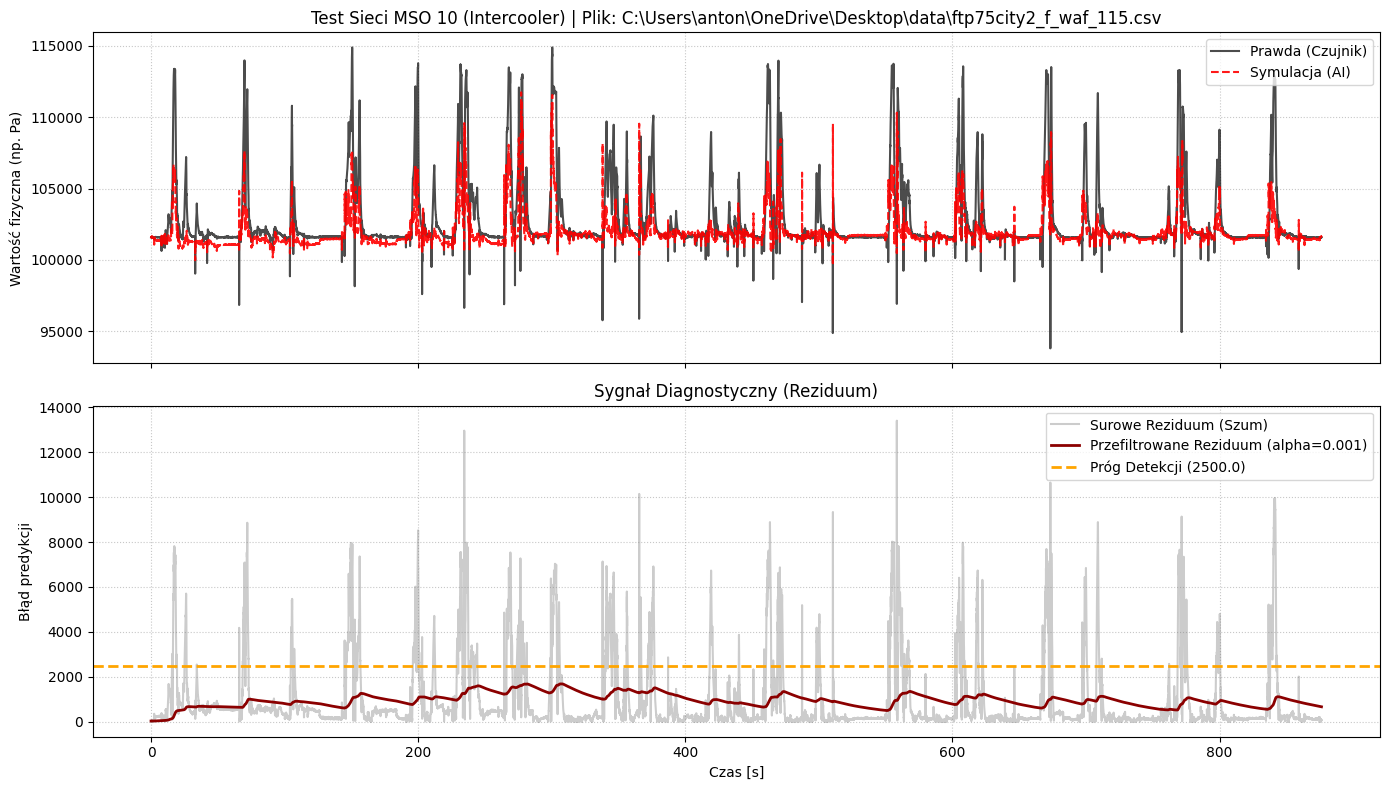

Średni błąd bezwzględny (MAE po rozgrzewce): 985.8857
Maksymalny błąd przefiltrowany (po rozgrzewce): 1682.1730


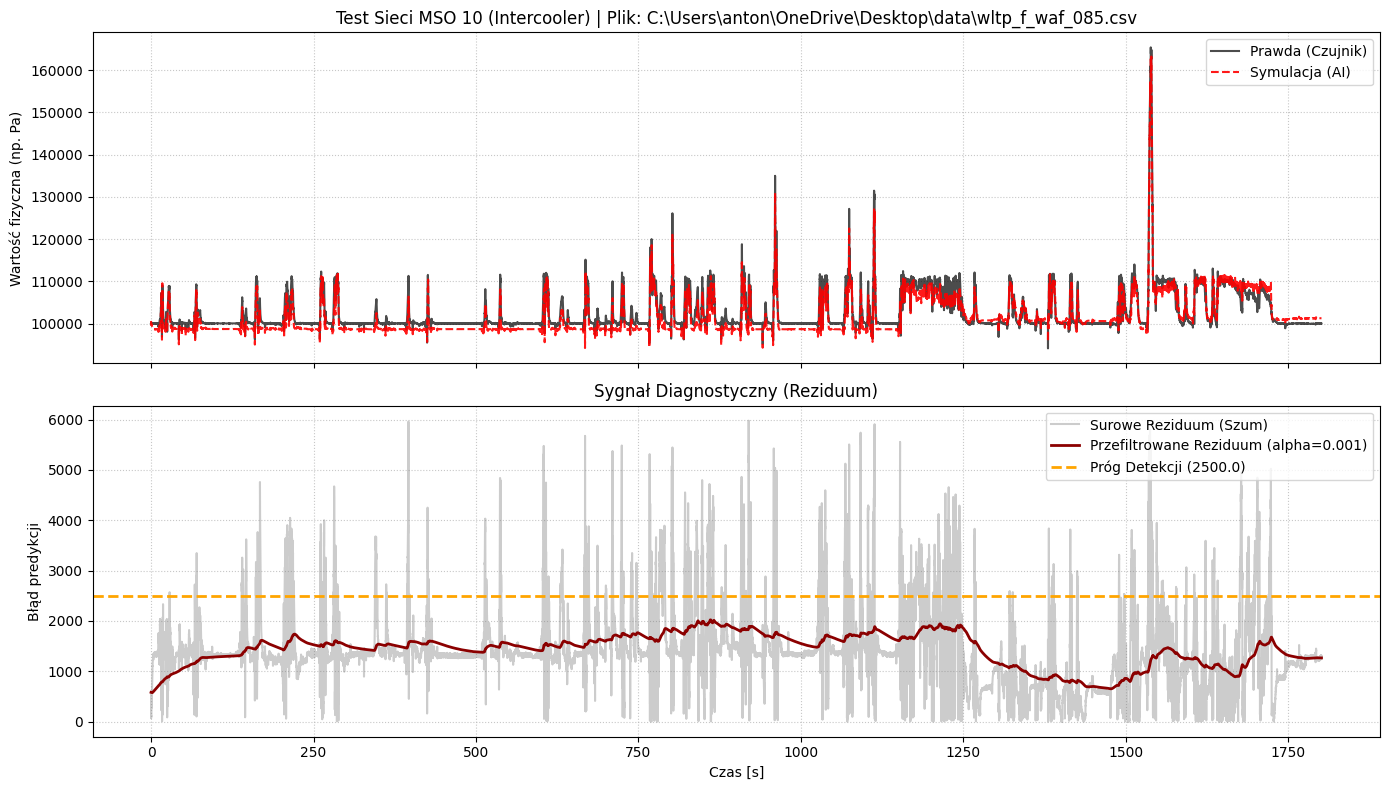

Średni błąd bezwzględny (MAE po rozgrzewce): 1452.0780
Maksymalny błąd przefiltrowany (po rozgrzewce): 2023.0272


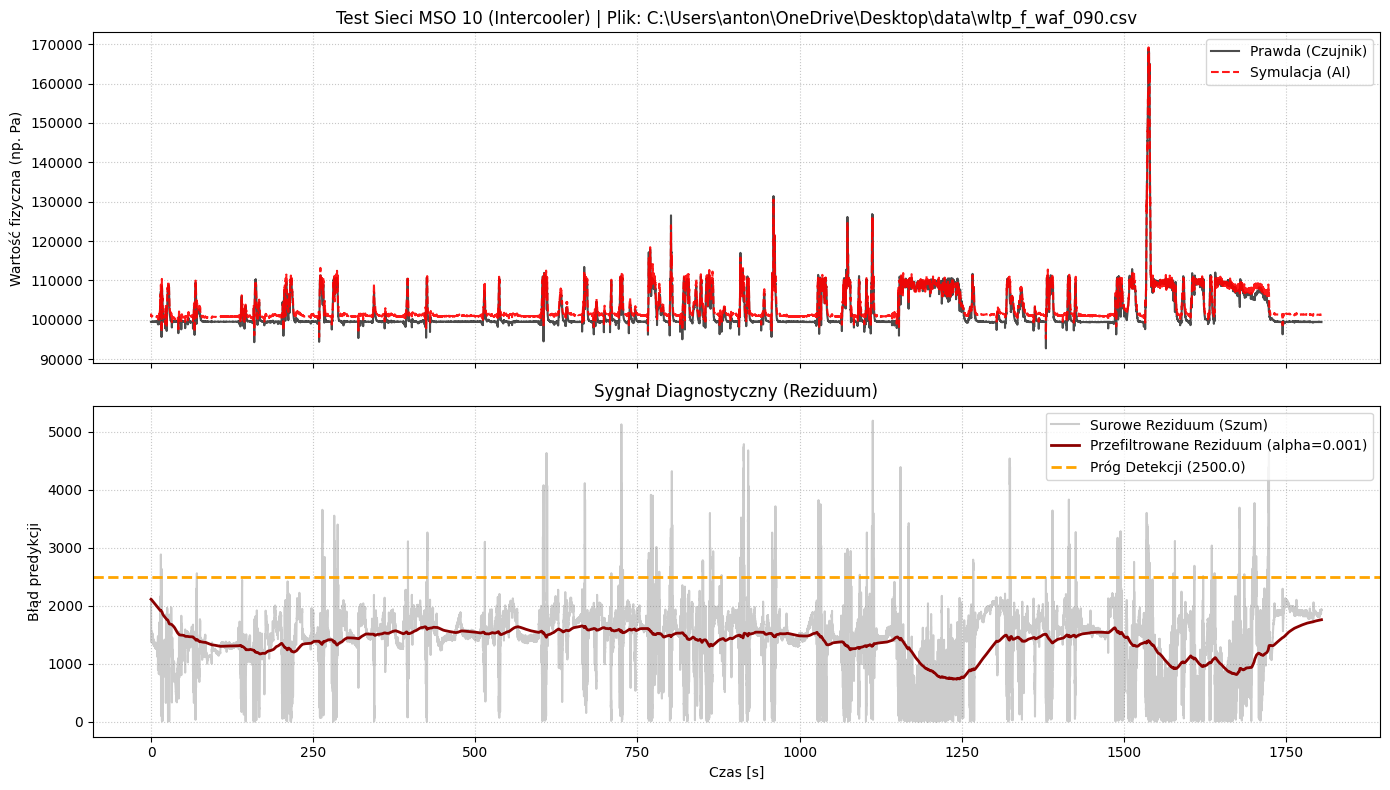

Średni błąd bezwzględny (MAE po rozgrzewce): 1381.2822
Maksymalny błąd przefiltrowany (po rozgrzewce): 2111.5391


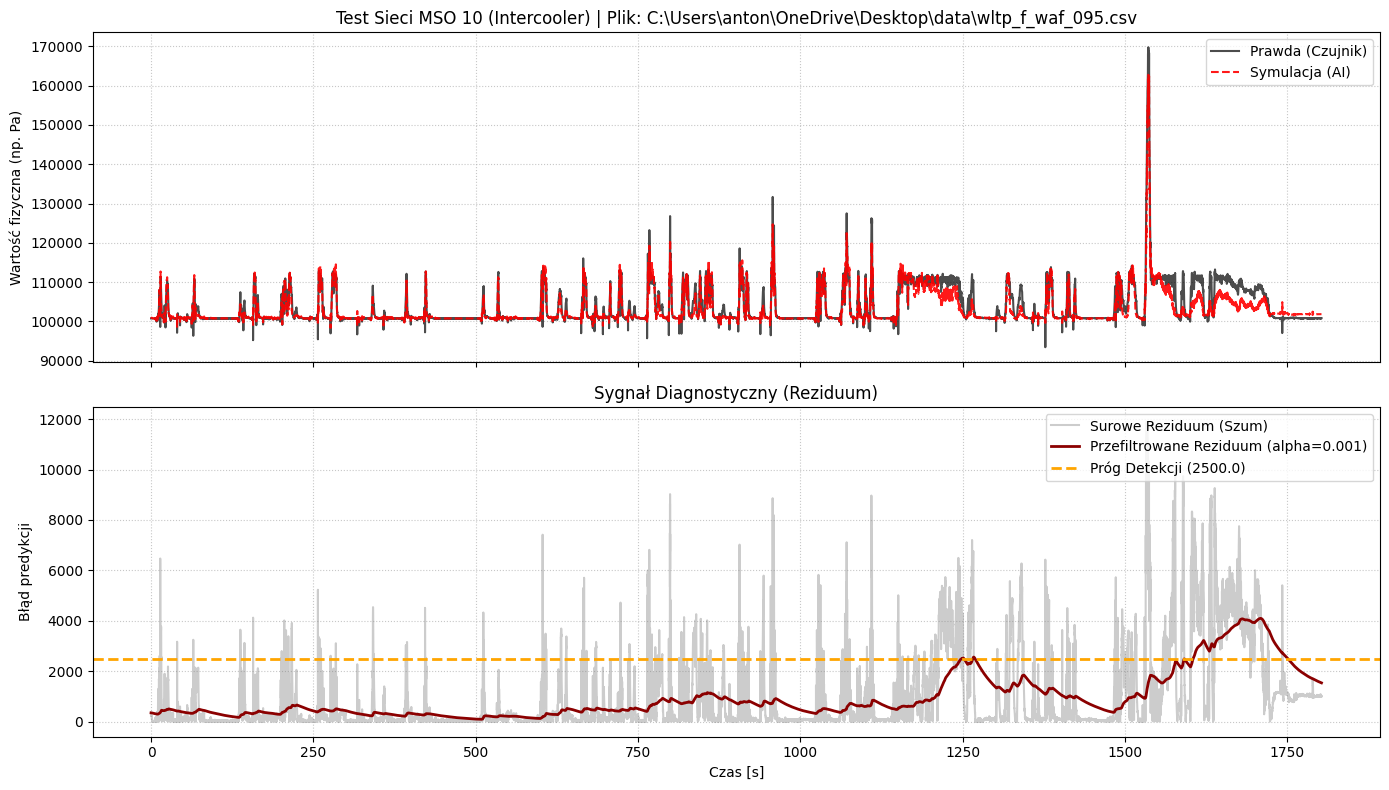

Średni błąd bezwzględny (MAE po rozgrzewce): 996.9977
Maksymalny błąd przefiltrowany (po rozgrzewce): 4097.9614


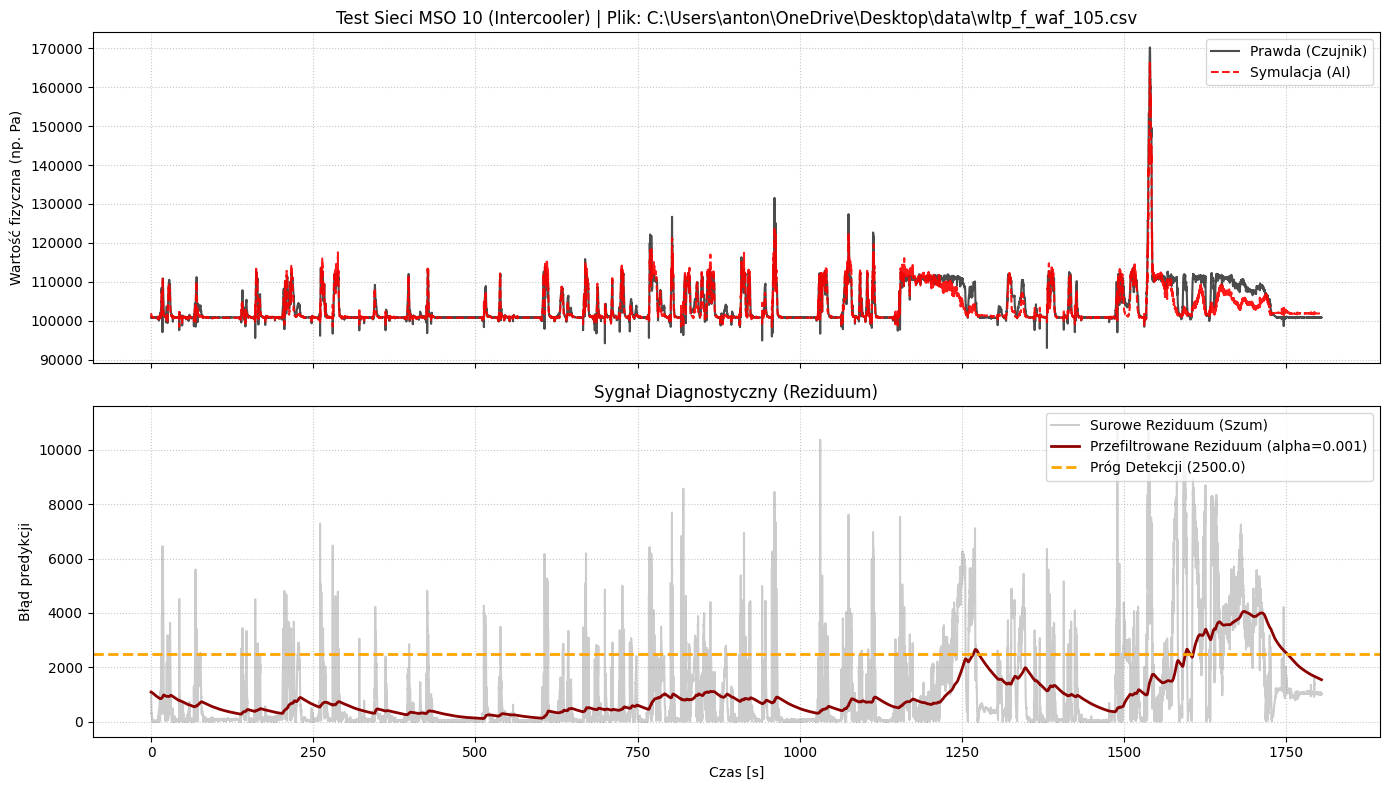

Średni błąd bezwzględny (MAE po rozgrzewce): 1017.6005
Maksymalny błąd przefiltrowany (po rozgrzewce): 4055.2161


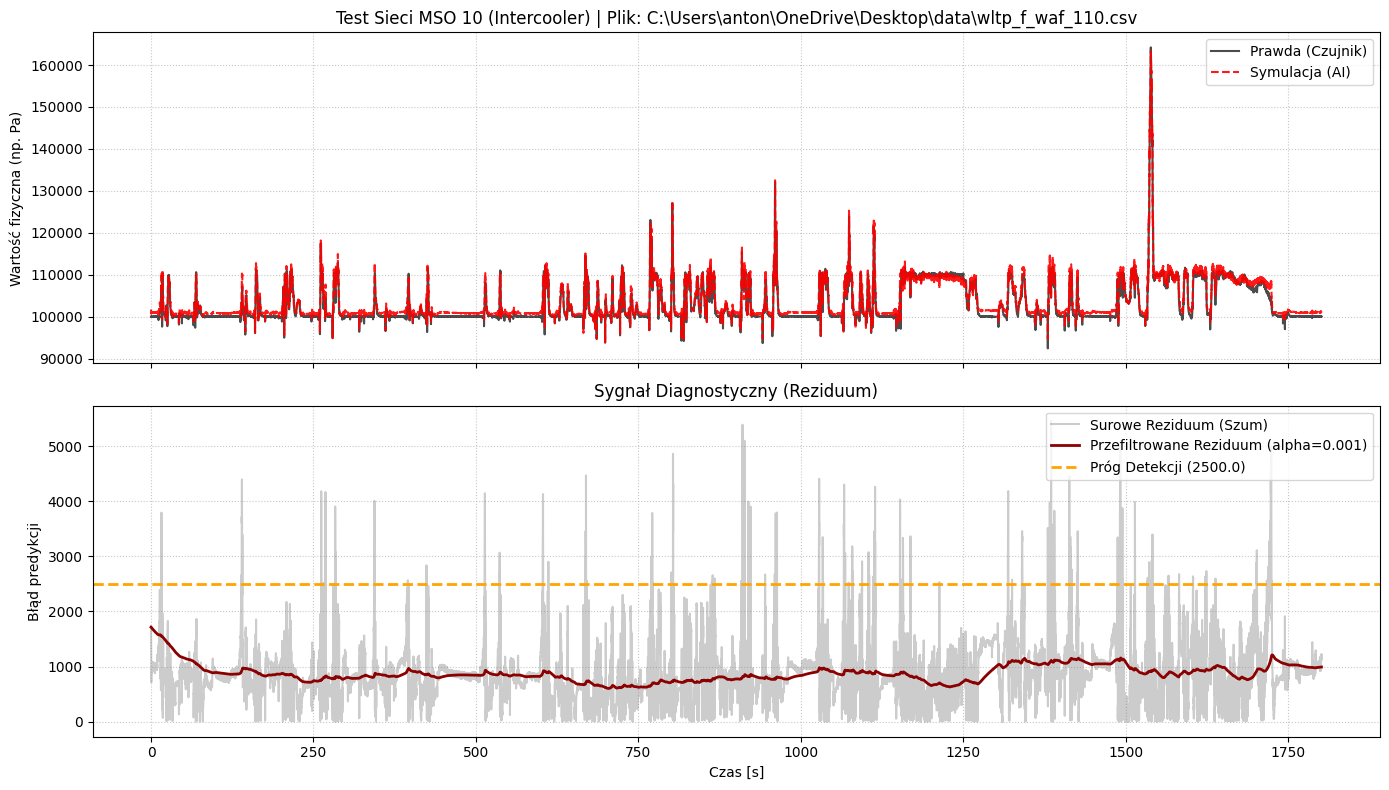

Średni błąd bezwzględny (MAE po rozgrzewce): 858.1605
Maksymalny błąd przefiltrowany (po rozgrzewce): 1716.3203


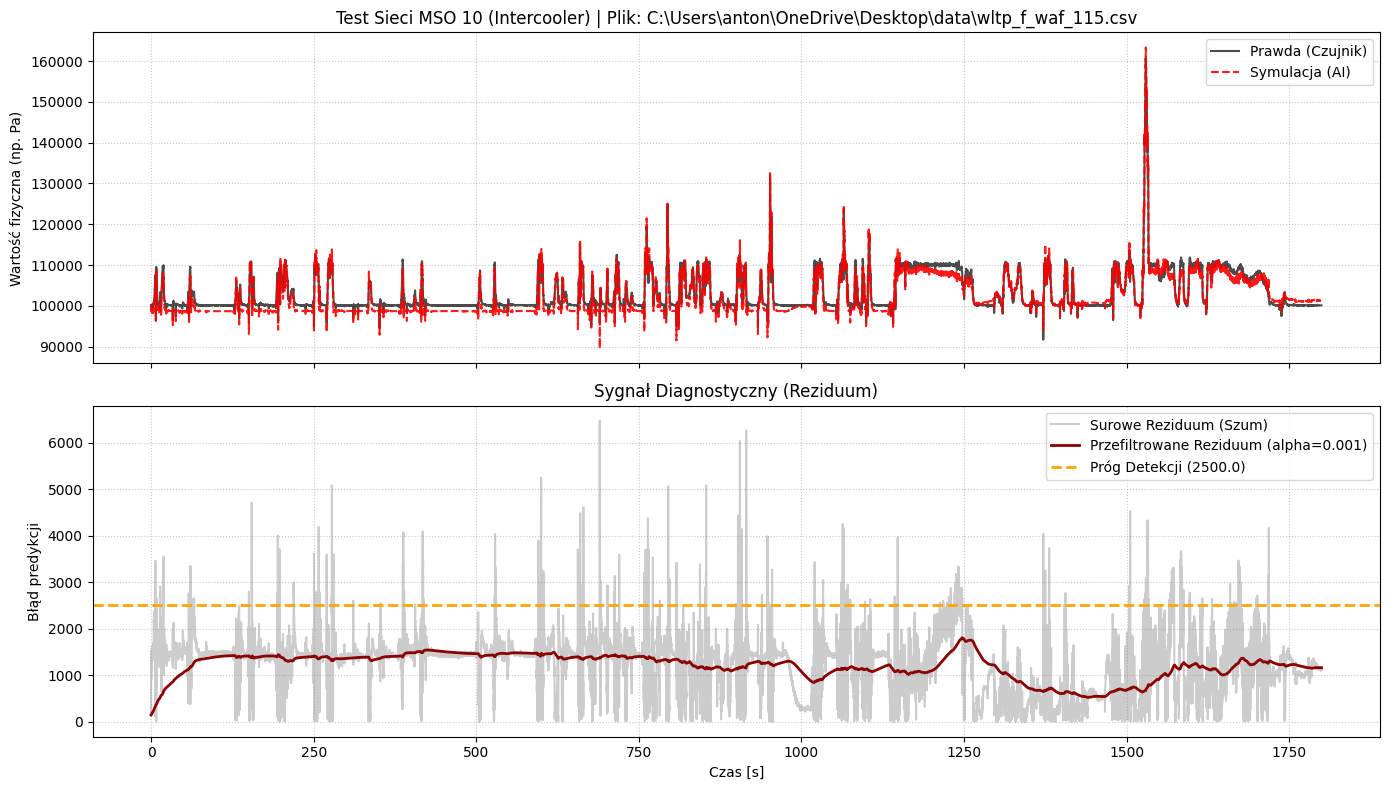

Średni błąd bezwzględny (MAE po rozgrzewce): 1230.0742
Maksymalny błąd przefiltrowany (po rozgrzewce): 1806.0164


In [5]:
model10 = GreyBoxSystem_MSO10(T_sample=0.05)

# Wczytanie wag i skalerów dla wersji z 2 stanami
model10.load_state_dict(torch.load('szara_skrzynka_mso10_wagi_2_stany.pth'))
model10.eval() # Ustawienie modelu w tryb predykcji

scaler_u10 = joblib.load('scaler_u_mso10_2_stany.pkl')
scaler_y10 = joblib.load('scaler_y_mso10_2_stany.pkl')

print("Model MSO 10 (2 stany) i skalery zostały pomyślnie wczytane z dysku!")

DATA_DIR = r"C:\Users\anton\OneDrive\Desktop\data"

HEALTHY_FILES = glob.glob(os.path.join(DATA_DIR, "*_NF*.csv"))
FAULTY_FILES_PIM = glob.glob(os.path.join(DATA_DIR, "*_f_pim*.csv"))
FAULTY_FILES_PIC = glob.glob(os.path.join(DATA_DIR, "*_f_pic*.csv"))
FAULTY_FILES_WAF = glob.glob(os.path.join(DATA_DIR, "*_f_waf*.csv"))
FAULTY_FILES_IML = glob.glob(os.path.join(DATA_DIR, "*_f_iml*.csv"))

pliki_testowe = [FAULTY_FILES_PIC, FAULTY_FILES_PIM, FAULTY_FILES_WAF]

for pliki in pliki_testowe:
    for plik_testowy in pliki:
        validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.001, threshold=2500.0)

Bez detekcji

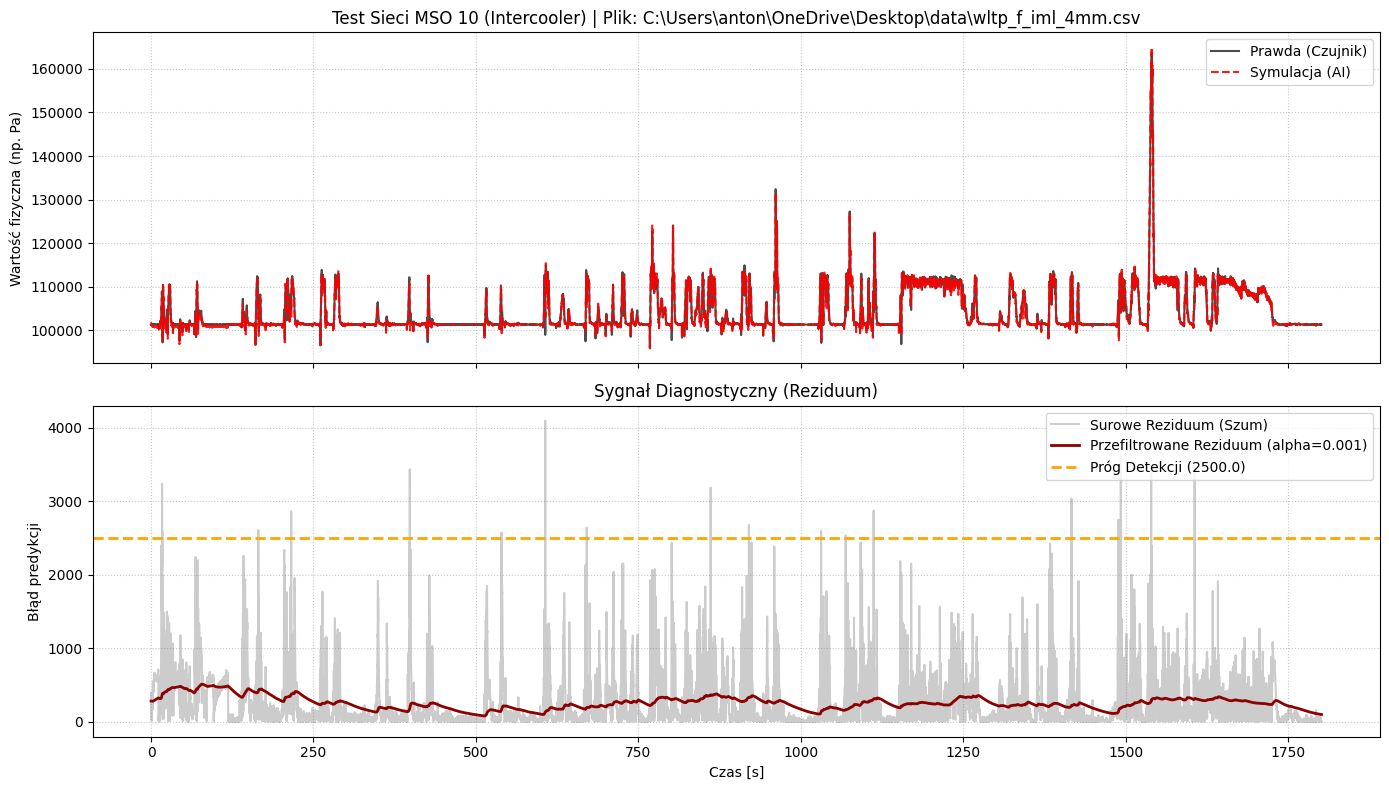

Średni błąd bezwzględny (MAE po rozgrzewce): 250.6337
Maksymalny błąd przefiltrowany (po rozgrzewce): 510.5922


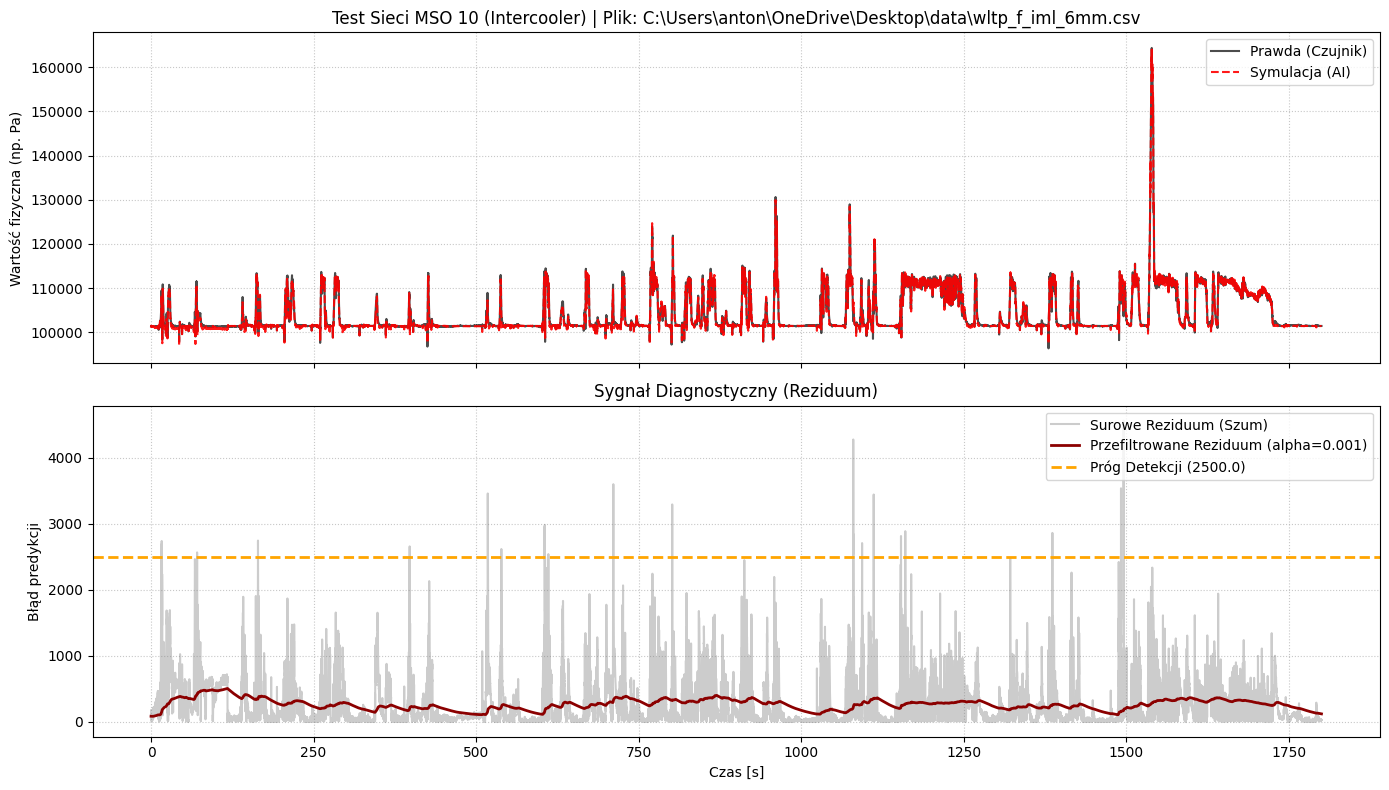

Średni błąd bezwzględny (MAE po rozgrzewce): 263.4494
Maksymalny błąd przefiltrowany (po rozgrzewce): 503.7754


In [ ]:
pliki_testowe = FAULTY_FILES_IML

for plik_testowy in pliki_testowe:
    validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.001, threshold=2500.0)